# CNT Dispersion Optimizer — Audit & Extension (Corrected NSGA-II)

**Basis:** Jintoku, *Machine-Learning-Based Dispersion Optimizer for Carbon Nanotubes across Dispersant-Solvent-Process Space*, ACS Appl. Mater. Interfaces 2026, 18, 22287–22299, DOI 10.1021/acsami.6c01563.

This notebook preserves the original audit workflow but corrects two methodological defects identified in the original optimizer implementation:

1. **NSGA-II constraints are enforced during optimization.** Applicability-domain (kNN) distance and RF tree-spread uncertainty are evaluated for every candidate and passed to `pymoo` as inequality constraints (`G <= 0`). The constrained NSGA-II front is compared against an **equivalently constrained enumeration front**, not the unconstrained enumeration.
2. **RME and sonication have independent process genes.** The decision vector now contains separate normalized genes for `log10_RME` and `log10_sonic`; changing one cannot silently change the other.
3. **Continuous genes are sampled continuously.** The original `IntegerRandomSampling()` was inappropriate for the normalized continuous process/composition genes. The corrected implementation uses continuous sampling and rounds only the explicitly discrete index genes during decoding.

All Pareto rows remain surrogate-model hypotheses requiring experimental validation.

## 0. Setup

In [1]:
import os, sys, warnings, time, importlib.util, subprocess
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

for module_name, package_name in [("pymoo", "pymoo"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm")]:
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import KFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.base import clone, BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore", category=UserWarning); warnings.filterwarnings("ignore", category=FutureWarning)
SEED=42; np.random.seed(SEED)
USE_BOOSTED_MODELS_FOR_BENCHMARK = False
PIPELINE_STAGES = {
    "data_loaded": False,
    "data_audit": False,
    "features_prepared": False,
    "grouped_cv": False,
    "external_validation": False,
    "applicability_domain": False,
    "enumeration": False,
    "constrained_front": False,
    "optimizer": False,
    "candidates_saved": False,
}

CANDIDATE_DATA_DIRS = [
    Path("/run/media/atharva/STUDY/project nano chemix/uploads"),
    Path("/mnt/user-data/uploads"),
    Path("/home/workdir/attachments"),
    Path("/mnt/data"),
    Path("/run/media/atharva/STUDY/project nano chemix")
]
DATA_DIR=next((p for p in CANDIDATE_DATA_DIRS if p.exists() and (p/"am6c01563_si_003.csv").exists()),CANDIDATE_DATA_DIRS[0])

# Updated to use the same project directory for outputs
REQUESTED_OUT_DIR=Path("/run/media/atharva/STUDY/project nano chemix")

try: REQUESTED_OUT_DIR.mkdir(parents=True,exist_ok=True); OUT_DIR=REQUESTED_OUT_DIR
except Exception: OUT_DIR=Path.cwd()/"outputs"; OUT_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUT_DIR/"figures"; FIG_DIR.mkdir(parents=True,exist_ok=True)

HAS_XGB = HAS_LGBM = True
HAS_PYMOO=False
try:
    import pymoo
    from pymoo.core.problem import Problem
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.operators.sampling.rnd import FloatRandomSampling
    from pymoo.operators.crossover.sbx import SBX
    from pymoo.operators.mutation.pm import PM
    from pymoo.operators.repair.rounding import RoundingRepair
    from pymoo.optimize import minimize as pymoo_minimize
    from pymoo.indicators.hv import HV
    from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
    HAS_PYMOO=True
except ImportError: pass

print("Python:",sys.version.split()[0],"| numpy:",np.__version__,"| pandas:",pd.__version__,"| sklearn:",__import__("sklearn").__version__)
print("xgboost:",xgb.__version__,"| lightgbm:",lgb.__version__,"| pymoo:",pymoo.__version__ if HAS_PYMOO else "N/A")
print("BOOSTED BENCHMARKS:",USE_BOOSTED_MODELS_FOR_BENCHMARK)
print("SEED =",SEED,"| DATA_DIR =",DATA_DIR,"| OUT_DIR =",OUT_DIR)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":150,"font.size":10,"axes.titlesize":11,"axes.labelsize":10,"legend.fontsize":8})

Python: 3.11.14 | numpy: 2.2.6 | pandas: 2.3.3 | sklearn: 1.7.2
xgboost: 3.2.0 | lightgbm: 4.7.0 | pymoo: 0.6.2
BOOSTED BENCHMARKS: False
SEED = 42 | DATA_DIR = /run/media/atharva/STUDY/project nano chemix/uploads | OUT_DIR = /run/media/atharva/STUDY/project nano chemix


In [2]:
def _norm(s): return "".join(ch.lower() for ch in str(s) if ch.isalnum())
ROLE_ALIASES={
 "identity":[["Dispersion_ID"],["dispersionid"],["ID"],["id"]],
 "smiles_D":[["smiles_D"],["smilesd"],["dispersantsmiles"]],
 "smiles_S":[["smiles_S"],["smiless"],["solventsmiles"]],
 "dispersant":[["dispersant"],["dispersantname"]],
 "solvent":[["solvent"],["solventname"]],
 "dispersant_category":[["dispersant_categoly"],["dispersantcategory"],["dispersant_type"]],
 "solvent_category":[["solvent_categoly"],["solventcategory"],["solvent_type"]],
 "pred_dscore":[["Predicted Dscore"],["predicteddscore"]],
 "pred_igid":[["Predicted IG/ID"],["predictedigid"]],
 "Dscore":[["Dscore"],["dscore"]],
 "IG/ID":[["IG/ID"],["IGID"],["igid"]],
 "process_sequence":[["process_sequence"],["processsequence"]],
 "carbon":[["carbon"],["CNT type"],["CNT_type"],["CNTtype"],["SWCNT type"],["SWCNT_type"]]}
def resolve_column(columns,aliases,required=True):
    normed={_norm(c):c for c in columns}
    for group in aliases:
        for alias in group:
            if _norm(alias) in normed: return normed[_norm(alias)]
    if required: raise KeyError(f"Could not resolve required column: {aliases}")
    return None
print("Actual CSV headers will be resolved programmatically after loading.")


Actual CSV headers will be resolved programmatically after loading.


## 1. Data Audit

In [3]:
train_path=DATA_DIR/"am6c01563_si_003.csv"; val_path=DATA_DIR/"am6c01563_si_004.csv"
DATA_AVAILABLE=train_path.exists() and val_path.exists()
print("=== INPUT PREFLIGHT ===")
print("Training:",train_path,"exists=",train_path.exists()); print("Validation:",val_path,"exists=",val_path.exists())
if not DATA_AVAILABLE:
    print("[BLOCKED] Required CSVs are not available. No scientific result is fabricated.")
else:
    df_train=pd.read_csv(train_path); df_val=pd.read_csv(val_path)

    def canonicalize(df, required_roles):
        d=df.copy(); mapping={}
        for canon,aliases in ROLE_ALIASES.items():
            actual=resolve_column(d.columns,aliases,required=canon in required_roles)
            if actual is not None and actual!=canon and canon not in d.columns: mapping[actual]=canon
        return d.rename(columns=mapping),mapping

    optional_roles={"identity","smiles_D","smiles_S"}
    train_required_roles=set(ROLE_ALIASES)-optional_roles
    val_required_roles=train_required_roles-{"dispersant_category","solvent_category"}
    df_train,train_mapping=canonicalize(df_train,train_required_roles)
    df_val,val_mapping=canonicalize(df_val,val_required_roles)

    if "categoly" not in df_val.columns:
        cc=resolve_column(df_val.columns,[["categoly"],["category"],["testcategory"]],False)
        if cc: df_val=df_val.rename(columns={cc:"categoly"})
    if "categoly" not in df_val.columns:
        raise KeyError("Validation CSV must include a test split column such as 'categoly'.")

    print("Training shape:",df_train.shape,"Validation shape:",df_val.shape)
    print("Validation categories:",df_val["categoly"].value_counts(dropna=False).to_dict())
    print("\n=== DATA DICTIONARY ===")
    for c in df_train.columns:
        miss=int(df_train[c].isna().sum()); ex=df_train[c].dropna().iloc[0] if miss<len(df_train) else None
        print(f"{c:32s} dtype={str(df_train[c].dtype):12s} nuniq={df_train[c].nunique(dropna=False):5d} miss={miss:4d} example={ex!r}")
    print("Resolved train mapping:",train_mapping); print("Resolved val mapping:",val_mapping)
    PIPELINE_STAGES["data_loaded"] = True

=== INPUT PREFLIGHT ===
Training: /run/media/atharva/STUDY/project nano chemix/uploads/am6c01563_si_003.csv exists= True
Validation: /run/media/atharva/STUDY/project nano chemix/uploads/am6c01563_si_004.csv exists= True
Training shape: (669, 51) Validation shape: (65, 52)
Validation categories: {'extrapolative test': 56, 'interpolation test': 9}

=== DATA DICTIONARY ===
identity                         dtype=int64        nuniq=  669 miss=   0 example=np.int64(1)
carbon                           dtype=object       nuniq=    2 miss=   0 example='eDIPS'
wt%                              dtype=float64      nuniq=    8 miss=   0 example=np.float64(0.05)
Disp/Carbon                      dtype=float64      nuniq=   13 miss=   0 example=np.float64(3.0)
dispersant                       dtype=object       nuniq=   36 miss=   0 example='AC'
dispersant_category              dtype=object       nuniq=    3 miss=   0 example='polymer'
smiles_D                         dtype=object       nuniq=   36 mis

In [4]:
if DATA_AVAILABLE:
    def check(name,condition,detail=""):
        status="PASS" if bool(condition) else "FAIL"
        print(f"[{status}] {name}"+(f" — {detail}" if detail else ""))
        return bool(condition)

    facts={}
    n_pairs=df_train.groupby(["dispersant","solvent"]).ngroups; facts["n_pairs"]=n_pairs
    check("289 unique dispersant-solvent pairs",n_pairs==289,f"got {n_pairs}")
    pc=df_train.groupby(["dispersant","solvent"]).size(); check("median pair has 1 row",pc.median()==1,f"median={pc.median():g}")
    check("36 dispersants",df_train.dispersant.nunique()==36); check("22 solvents",df_train.solvent.nunique()==22); check("2 CNT types",df_train.carbon.nunique()==2)
    water=df_train.solvent_category.astype(str).str.strip().str.lower().str.contains("water",na=False); nonwater=~water
    check("ESOL_LogS_D NaN for 100% non-water",df_train.loc[nonwater,"ESOL_LogS_D"].isna().mean()==1)
    check("ESOL_LogS_D present for water",df_train.loc[water,"ESOL_LogS_D"].isna().mean()==0)
    check("delta_mr NaN for 100% water",df_train.loc[water,"delta_mr"].isna().mean()==1)
    check("delta_mr present for non-water",df_train.loc[nonwater,"delta_mr"].isna().mean()==0)
    igid_miss=df_train.groupby("dispersant_category")["IG/ID"].apply(lambda x:x.isna().mean()); print("IG/ID missing fractions:\n",igid_miss.round(3))
    check("IG/ID missing about 51% of dye rows",.40<=igid_miss.get("dye",np.nan)<=.60,f"dye={igid_miss.get('dye',np.nan):.3f}")
    check("IG/ID missing about 22% of polymer rows",.15<=igid_miss.get("polymer",np.nan)<=.30,f"polymer={igid_miss.get('polymer',np.nan):.3f}")
    check("IG/ID missing 0% of surfactant rows",igid_miss.get("surfactant",np.nan)==0,f"surfactant={igid_miss.get('surfactant',np.nan):.3f}")
    sim_nan=df_train.SimMCS.isna().sum(); check("SimMCS has about 34 NaNs",25<=sim_nan<=45,f"got {sim_nan}")
    check("Dscore nearly complete",df_train.Dscore.notna().sum()>=660,f"n={df_train.Dscore.notna().sum()}")
    check("IG/ID about 496 measured",490<=df_train["IG/ID"].notna().sum()<=510,f"n={df_train['IG/ID'].notna().sum()}")
    print(f"Observed pairs={n_pairs}; possible=792; unobserved={792-n_pairs}")
    PIPELINE_STAGES["data_audit"] = True

[PASS] 289 unique dispersant-solvent pairs — got 289
[PASS] median pair has 1 row — median=1
[PASS] 36 dispersants
[PASS] 22 solvents
[PASS] 2 CNT types
[PASS] ESOL_LogS_D NaN for 100% non-water
[PASS] ESOL_LogS_D present for water
[PASS] delta_mr NaN for 100% water
[PASS] delta_mr present for non-water
IG/ID missing fractions:
 dispersant_category
dye           0.507
polymer       0.216
surfactant    0.000
Name: IG/ID, dtype: float64
[PASS] IG/ID missing about 51% of dye rows — dye=0.507
[PASS] IG/ID missing about 22% of polymer rows — polymer=0.216
[PASS] IG/ID missing 0% of surfactant rows — surfactant=0.000
[PASS] SimMCS has about 34 NaNs — got 34
[PASS] Dscore nearly complete — n=666
[PASS] IG/ID about 496 measured — n=496
Observed pairs=289; possible=792; unobserved=503


Columns with missing values (train):
sonication energy step 3    0.9656
sonication energy step 2    0.9626
mixing rpm step 2           0.8700
RME step 2                  0.8700
ESOL_LogS_D                 0.7758
RME step 1                  0.6846
mixing rpm step 1           0.6846
sonication energy step 1    0.3154
pred_igid                   0.2586
IG/ID                       0.2586
delta_mr                    0.2242
delta_tpsa                  0.2242
SimMCS                      0.0508
Dscore                      0.0045
pred_dscore                 0.0045


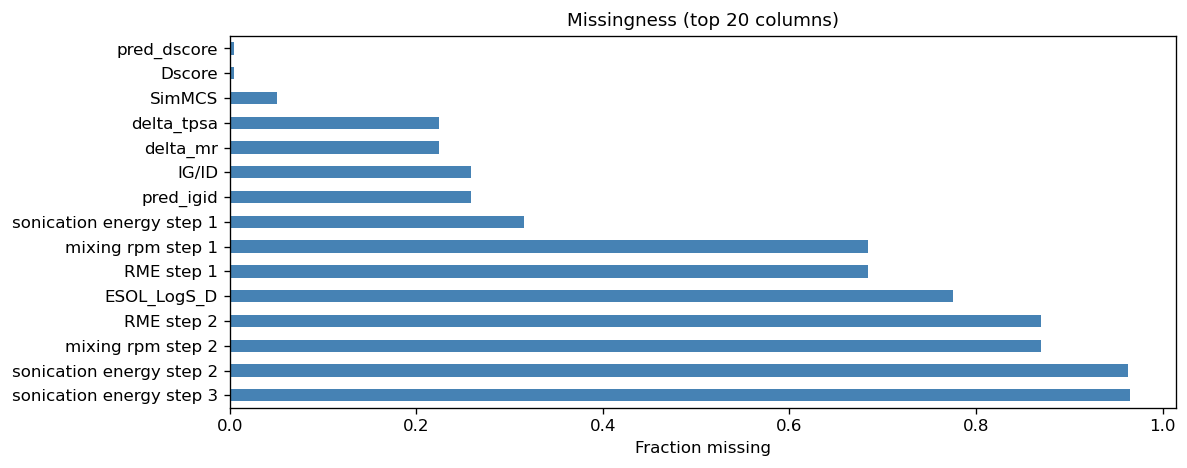

In [5]:
if DATA_AVAILABLE:
    # Missingness overview
    miss_frac = df_train.isna().mean().sort_values(ascending=False)
    miss_frac = miss_frac[miss_frac > 0]
    print("Columns with missing values (train):")
    print(miss_frac.round(4).to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    miss_frac.head(20).plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("Fraction missing")
    ax.set_title("Missingness (top 20 columns)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "01_missingness.png", bbox_inches="tight")
    plt.show()


In [6]:
if DATA_AVAILABLE:
    # Design confounding table: factor levels per process_sequence
    print("=== DESIGN CONFOUNDING: factor ranges by process_sequence ===")
    proc_cols = ["wt%", "Disp/Carbon", "mixing rpm step 1", "RME step 1",
                 "sonication energy step 1"]
    confound = []
    for ps, g in df_train.groupby("process_sequence"):
        row = {"process_sequence": ps, "n": len(g)}
        for c in proc_cols:
            vals = g[c].dropna()
            if len(vals):
                row[f"{c}_min"] = vals.min()
                row[f"{c}_max"] = vals.max()
                row[f"{c}_nuniq"] = vals.nunique()
            else:
                row[f"{c}_min"] = np.nan
                row[f"{c}_max"] = np.nan
                row[f"{c}_nuniq"] = 0
        confound.append(row)
    confound_df = pd.DataFrame(confound).set_index("process_sequence")
    display(confound_df)

    print("\nNOTE: HF_2step is largely fixed at 10,000 rpm; HF_1step+Bath uses only 0.05 wt% and Disp/Carbon 2–3;")
    print("Bath reaches Disp/Carbon up to 30 while HF_1step stops at 4. Process dominance of IG/ID is partly a DoE artifact.")


=== DESIGN CONFOUNDING: factor ranges by process_sequence ===


,n,wt%_min,wt%_max,wt%_nuniq,Disp/Carbon_min,Disp/Carbon_max,Disp/Carbon_nuniq,mixing rpm step 1_min,mixing rpm step 1_max,mixing rpm step 1_nuniq,RME step 1_min,RME step 1_max,RME step 1_nuniq,sonication energy step 1_min,sonication energy step 1_max,sonication energy step 1_nuniq
process_sequence,,,,,,,,,,,,,,,,
Bath,458,0.0500,0.25,3,1.0,30.0,12,NaN,NaN,0,NaN,NaN,0,9.0,324.0,8
HF_1step,99,0.0500,0.20,2,1.0,4.0,4,5000.0,15000.0,5,6.890284e+10,1.400000e+13,25,NaN,NaN,0
HF_1step + Bath,25,0.0500,0.05,1,2.0,3.0,2,6000.0,15000.0,4,8.930000e+11,1.400000e+13,4,NaN,NaN,0
HF_2step,64,0.0125,0.30,5,1.0,10.0,8,10000.0,10000.0,1,3.450000e+11,1.380000e+12,3,NaN,NaN,0
HF_2step + Bath,23,0.0500,0.30,3,2.0,10.0,5,10000.0,10000.0,1,6.890000e+11,1.380000e+12,2,NaN,NaN,0



NOTE: HF_2step is largely fixed at 10,000 rpm; HF_1step+Bath uses only 0.05 wt% and Disp/Carbon 2–3;
Bath reaches Disp/Carbon up to 30 while HF_1step stops at 4. Process dominance of IG/ID is partly a DoE artifact.


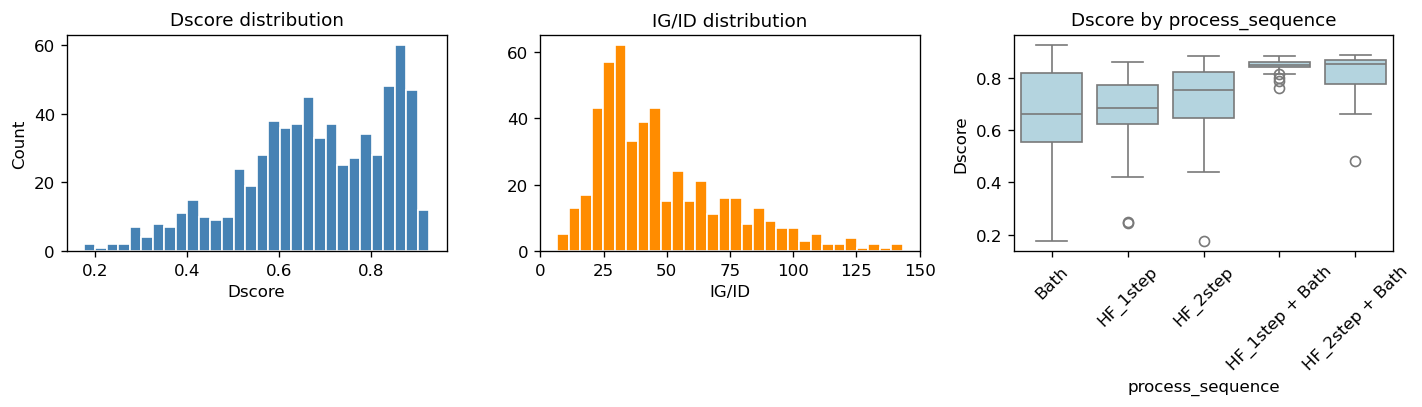

Dispersant category counts:
dispersant_category
polymer       476
dye           138
surfactant     55
Name: count, dtype: int64

Solvent category counts:
solvent_category
organic_solvent    519
water              150
Name: count, dtype: int64


In [7]:
if DATA_AVAILABLE:
    # Target histograms + correlation by process
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].hist(df_train["Dscore"].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Dscore"); axes[0].set_ylabel("Count"); axes[0].set_title("Dscore distribution")
    axes[1].hist(df_train["IG/ID"].dropna(), bins=30, color="darkorange", edgecolor="white")
    axes[1].set_xlabel("IG/ID"); axes[1].set_title("IG/ID distribution")

    order = df_train.groupby("process_sequence")["Dscore"].median().sort_values().index
    sns.boxplot(data=df_train, x="process_sequence", y="Dscore", order=order, ax=axes[2], color="lightblue")
    axes[2].tick_params(axis="x", rotation=45)
    axes[2].set_title("Dscore by process_sequence")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_target_distributions.png", bbox_inches="tight")
    plt.show()

    # Class balance
    print("Dispersant category counts:")
    print(df_train["dispersant_category"].value_counts())
    print("\nSolvent category counts:")
    print(df_train["solvent_category"].value_counts())

## 2. Feature Pipeline

In [8]:
if DATA_AVAILABLE:
    def prepare_features(df: pd.DataFrame, fit_ref: Optional[pd.DataFrame] = None) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
        """Prepare model-ready features; log10 energy fields use log10(1 + energy)."""
        d = df.copy()

        # is_water flag
        if "solvent_category" in d.columns:
            d["is_water"] = d["solvent_category"].astype("string").str.strip().str.lower().eq("water").astype(float)
        elif "solvent" in d.columns:
            d["is_water"] = d["solvent"].astype("string").str.strip().str.lower().eq("water").astype(float)
        else:
            d["is_water"] = 0.0

        # Structural fill
        for col in ["ESOL_LogS_D", "delta_mr", "delta_tpsa"]:
            if col in d.columns:
                d[col] = d[col].fillna(0.0)

        # Aggregate process energies
        rme_cols = [c for c in d.columns if c.startswith("RME")]
        sonic_cols = [c for c in d.columns if c.startswith("sonication energy")]
        rpm_cols = [c for c in d.columns if "rpm" in c.lower()]

        d["RME_total"] = d[rme_cols].fillna(0).sum(axis=1) if rme_cols else 0.0
        d["sonic_total"] = d[sonic_cols].fillna(0).sum(axis=1) if sonic_cols else 0.0
        d["rpm_max"] = d[rpm_cols].fillna(0).max(axis=1) if rpm_cols else 0.0

        # log10(1 + energy) preserves an exact zero-energy state.
        d["log10_RME"] = np.log10(1.0 + d["RME_total"])
        d["log10_sonic"] = np.log10(1.0 + d["sonic_total"])

        # Fill process_sequence blanks (extrapolative rows)
        if "process_sequence" in d.columns:
            d["process_sequence"] = d["process_sequence"].fillna("Bath")

        # Targets
        y_d = d["Dscore"] if "Dscore" in d.columns else pd.Series(np.nan, index=d.index)
        y_i = d["IG/ID"] if "IG/ID" in d.columns else pd.Series(np.nan, index=d.index)

        return d, y_d, y_i


    # Descriptor / feature groups (after prepare)
    MOL_D = [c for c in df_train.columns if c.endswith("_D") and c not in ("smiles_D",)]
    MOL_S = [c for c in df_train.columns if c.endswith("_S") and c not in ("smiles_S",)]
    SIM_COLS = ["SimMCS", "Simcos", "delta_mr", "delta_tpsa"]
    ENG_COLS = ["is_water", "RME_total", "sonic_total", "rpm_max", "log10_RME", "log10_sonic"]
    COMP_COLS = ["wt%", "Disp/Carbon"]
    CAT_COLS = ["carbon", "process_sequence"]

    print("Molecular _D:", MOL_D)
    print("Molecular _S:", MOL_S)
    print("Similarity:", SIM_COLS)
    print("Engineered:", ENG_COLS)

    ALL_NUM = COMP_COLS + MOL_D + MOL_S + SIM_COLS + ENG_COLS
    # Remove duplicates while preserving order
    seen = set()
    ALL_NUM = [c for c in ALL_NUM if not (c in seen or seen.add(c))]
    print(f"\nTotal candidate numeric features: {len(ALL_NUM)}")

Molecular _D: ['ESOL_LogS_D', 'EState_VSA2_D', 'EState_VSA4_D', 'EState_VSA5_D', 'HallKierAlpha_D', 'Kappa3_D', 'MaxEStateIndex_D', 'MinAbsEStateIndex_D', 'MinEStateIndex_D', 'PEOE_VSA6_D', 'VSA_EState5_D', 'VSA_EState8_D']
Molecular _S: ['BCUT2D_LOGPHI_S', 'BCUT2D_MRHI_S', 'BCUT2D_MRLOW_S', 'BCUT2D_MWHI_S', 'Chi1_S', 'Chi2n_S', 'FpDensityMorgan3_S', 'Kappa2_S', 'Kappa3_S', 'MinAbsEStateIndex_S', 'MolLogP_S', 'MolMR_S', 'VSA_EState8_S']
Similarity: ['SimMCS', 'Simcos', 'delta_mr', 'delta_tpsa']
Engineered: ['is_water', 'RME_total', 'sonic_total', 'rpm_max', 'log10_RME', 'log10_sonic']

Total candidate numeric features: 37


In [9]:
if DATA_AVAILABLE:
    train_prep, y_dscore, y_igid = prepare_features(df_train)
    val_prep, y_dscore_val, y_igid_val = prepare_features(df_val)

    # Ensure all numeric cols exist
    for c in ALL_NUM:
        if c not in train_prep.columns:
            train_prep[c] = 0.0
        if c not in val_prep.columns:
            val_prep[c] = 0.0

    # Masks
    mask_d = y_dscore.notna()
    mask_i = y_igid.notna()
    print(f"Dscore usable rows: {mask_d.sum()}")
    print(f"IG/ID usable rows:  {mask_i.sum()}")

    # Group keys for CV
    train_prep["pair_id"] = train_prep["dispersant"].astype(str) + "||" + train_prep["solvent"].astype(str)
    pair_ids = train_prep["pair_id"]
    solvent_ids = train_prep["solvent"]
    dispersant_ids = train_prep["dispersant"]

    print(f"Unique pairs: {pair_ids.nunique()}, solvents: {solvent_ids.nunique()}, dispersants: {dispersant_ids.nunique()}")
    # Coerce numeric feature columns to float
    for c in ALL_NUM:
        if c in train_prep.columns:
            train_prep[c] = pd.to_numeric(train_prep[c], errors="coerce")
        if c in val_prep.columns:
            val_prep[c] = pd.to_numeric(val_prep[c], errors="coerce")

    PIPELINE_STAGES["features_prepared"] = True

Dscore usable rows: 666
IG/ID usable rows:  496
Unique pairs: 289, solvents: 22, dispersants: 36


In [10]:
if DATA_AVAILABLE:
    class LowVarianceFilter(BaseEstimator, TransformerMixin):
        """Drop numeric columns with variance < threshold (fitted on train fold only)."""
        def __init__(self, threshold: float = 0.05):
            self.threshold = threshold
            self.keep_idx_: Optional[np.ndarray] = None

        def fit(self, X, y=None):
            X = np.asarray(X, dtype=float)
            with np.errstate(all="ignore"):
                var = np.nanvar(X, axis=0)
            var = np.where(np.isnan(var), 0.0, var)
            self.keep_idx_ = np.where(var >= self.threshold)[0]
            if len(self.keep_idx_) == 0:
                self.keep_idx_ = np.arange(X.shape[1])
            return self

        def transform(self, X):
            X = np.asarray(X, dtype=float)
            return X[:, self.keep_idx_]


    def make_pipeline(model, numeric_features: List[str], cat_features: List[str] = None,
                      scale: bool = False) -> Pipeline:
        """Build a leakage-safe sklearn Pipeline."""
        cat_features = cat_features or []
        # Ensure no overlap
        numeric_features = [c for c in numeric_features if c not in cat_features]
        transformers = []
        num_pipe_steps = [
            ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ]
        if scale:
            num_pipe_steps.append(("scaler", StandardScaler()))
        num_pipe_steps.append(("varfilter", LowVarianceFilter(0.05)))
        if numeric_features:
            transformers.append(("num", Pipeline(num_pipe_steps), numeric_features))

        if cat_features:
            transformers.append((
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                cat_features
            ))

        pre = ColumnTransformer(transformers, remainder="drop")
        return Pipeline([("pre", pre), ("model", model)])


    def get_models(seed: int = SEED) -> Dict[str, Any]:
        """Return dict of model name → (estimator, needs_scaling)."""
        models = {
            "MeanBaseline": ("mean", False),
            "Ridge": (Ridge(alpha=1.0, random_state=seed), True),
            "RF": (RandomForestRegressor(
                n_estimators=200, max_depth=12, min_samples_leaf=3,
                random_state=seed, n_jobs=-1), False),
            "HGB": (HistGradientBoostingRegressor(
                max_iter=200, max_depth=8, learning_rate=0.05,
                random_state=seed), False),
        }
        if USE_BOOSTED_MODELS_FOR_BENCHMARK:
            models["XGB"] = (xgb.XGBRegressor(
                n_estimators=200, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                random_state=seed, n_jobs=-1, verbosity=0), False)
            models["LGBM"] = (lgb.LGBMRegressor(
                n_estimators=200, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                random_state=seed, n_jobs=-1, verbosity=-1), False)
        return models


    original_benchmark_flag = USE_BOOSTED_MODELS_FOR_BENCHMARK
    try:
        USE_BOOSTED_MODELS_FOR_BENCHMARK = False
        baseline_model_names = set(get_models())
        USE_BOOSTED_MODELS_FOR_BENCHMARK = True
        boosted_model_names = set(get_models())
    finally:
        USE_BOOSTED_MODELS_FOR_BENCHMARK = original_benchmark_flag

    assert {"XGB", "LGBM"}.isdisjoint(baseline_model_names)
    assert {"XGB", "LGBM"}.issubset(boosted_model_names)
    assert {"MeanBaseline", "Ridge", "RF", "HGB"}.issubset(baseline_model_names)
    print("[PASS] Boosted-model flag toggles XGBoost and LightGBM; baseline models remain available.")

[PASS] Boosted-model flag toggles XGBoost and LightGBM; baseline models remain available.


## 3. Reproduction Check (paper-style random 10-fold)

In [11]:
if DATA_AVAILABLE:
    def pooled_oof_metrics(y_true, y_pred):
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
        if len(yt) < 5:
            return {"R2": np.nan, "MAE": np.nan, "RMSE": np.nan, "n": len(yt)}
        return {
            "R2": r2_score(yt, yp),
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
            "n": int(len(yt)),
        }


    def run_random_cv(X, y, model, scale, n_splits=10, seed=SEED):
        """Pooled out-of-fold predictions with KFold."""
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof = np.full(len(y), np.nan)
        num_f = [c for c in X.columns if c not in CAT_COLS]
        cat_f = [c for c in CAT_COLS if c in X.columns]
        for tr, te in kf.split(X):
            if model == "mean":
                oof[te] = np.nanmean(y.iloc[tr] if hasattr(y, "iloc") else y[tr])
            else:
                pipe = make_pipeline(clone(model), num_f, cat_f, scale=scale)
                pipe.fit(X.iloc[tr], y.iloc[tr] if hasattr(y, "iloc") else y[tr])
                oof[te] = pipe.predict(X.iloc[te])
        return oof


    # Feature matrix for reproduction (all numeric + cats present in train_prep)
    feat_cols = [c for c in ALL_NUM if c in train_prep.columns and c not in CAT_COLS]
    X_all = train_prep[feat_cols + CAT_COLS].copy()

    print("=== PAPER REPRODUCTION (random 10-fold OOF) ===")
    print(f"Paper claims: Dscore R2=0.57 MAE=0.08 | IG/ID R2=0.73 MAE=9.84")

    # Check Predicted* columns first
    pred_d = df_train["pred_dscore"]
    pred_i = df_train["pred_igid"]
    m_d_paper = pooled_oof_metrics(y_dscore[mask_d], pred_d[mask_d])
    m_i_paper = pooled_oof_metrics(y_igid[mask_i], pred_i[mask_i])
    print(f"\nFrom Predicted* columns:")
    print(f"  Dscore: R2={m_d_paper['R2']:.3f} MAE={m_d_paper['MAE']:.3f}  (paper 0.57 / 0.08)")
    print(f"  IG/ID:  R2={m_i_paper['R2']:.3f} MAE={m_i_paper['MAE']:.3f}  (paper 0.73 / 9.84)")

    dscore_match = abs(m_d_paper["R2"] - 0.57) < 0.03 and abs(m_d_paper["MAE"] - 0.08) < 0.02
    igid_match = abs(m_i_paper["R2"] - 0.73) < 0.03 and abs(m_i_paper["MAE"] - 9.84) < 1.0
    print(f"  Dscore Predicted* matches paper: {'matches' if dscore_match else 'does not match'}")
    print(f"  IG/ID  Predicted* matches paper: {'matches' if igid_match else 'does not match'}")

    # Our own random-CV with RF and best booster
    models = get_models()
    print("\nOur models (random 10-fold OOF):")
    repro_results = []
    for name, (est, scale) in models.items():
        if name == "MeanBaseline":
            oof_d = run_random_cv(X_all.loc[mask_d], y_dscore.loc[mask_d], "mean", False)
            oof_i = run_random_cv(X_all.loc[mask_i], y_igid.loc[mask_i], "mean", False)
        else:
            oof_d = run_random_cv(X_all.loc[mask_d], y_dscore.loc[mask_d], est, scale)
            oof_i = run_random_cv(X_all.loc[mask_i], y_igid.loc[mask_i], est, scale)
        md = pooled_oof_metrics(y_dscore.loc[mask_d], oof_d)
        mi = pooled_oof_metrics(y_igid.loc[mask_i], oof_i)
        print(f"  {name:12s}  Dscore R2={md['R2']:.3f} MAE={md['MAE']:.3f}  |  IG/ID R2={mi['R2']:.3f} MAE={mi['MAE']:.3f}")
        repro_results.append({"model": name, "target": "Dscore", **md})
        repro_results.append({"model": name, "target": "IG/ID", **mi})

    repro_df = pd.DataFrame(repro_results)


=== PAPER REPRODUCTION (random 10-fold OOF) ===
Paper claims: Dscore R2=0.57 MAE=0.08 | IG/ID R2=0.73 MAE=9.84

From Predicted* columns:
  Dscore: R2=0.566 MAE=0.078  (paper 0.57 / 0.08)
  IG/ID:  R2=0.728 MAE=9.837  (paper 0.73 / 9.84)
  Dscore Predicted* matches paper: matches
  IG/ID  Predicted* matches paper: matches

Our models (random 10-fold OOF):
  MeanBaseline  Dscore R2=-0.003 MAE=0.132  |  IG/ID R2=-0.003 MAE=20.931
  Ridge         Dscore R2=0.306 MAE=0.102  |  IG/ID R2=0.594 MAE=12.896
  RF            Dscore R2=0.527 MAE=0.082  |  IG/ID R2=0.673 MAE=10.990
  HGB           Dscore R2=0.532 MAE=0.081  |  IG/ID R2=0.673 MAE=11.096


## 4. Grouped-CV Audit (core)

In [12]:
if DATA_AVAILABLE:
    def make_group_splitter(groups,n_splits=5,seed=SEED):
        g=pd.Series(groups).reset_index(drop=True); uniq=g.unique(); rng=np.random.RandomState(seed); shuf=uniq.copy(); rng.shuffle(shuf)
        return GroupKFold(n_splits=min(n_splits,len(uniq))),g.map({old:i for i,old in enumerate(shuf)}).to_numpy()
    def run_grouped_cv(X,y,groups,model,scale,n_splits=5,seed=SEED):
        g=pd.Series(groups,index=X.index); splitter,gcode=make_group_splitter(g,n_splits,seed); oof=np.full(len(y),np.nan); mets=[]
        num_f=[c for c in X.columns if c not in CAT_COLS]; cat_f=[c for c in CAT_COLS if c in X.columns]
        for fold,(tr,te) in enumerate(splitter.split(X,y,gcode)):
            yt=y.iloc[tr]
            pred=np.full(len(te),np.nanmean(yt)) if model=="mean" else None
            if model!="mean":
                pipe=make_pipeline(clone(model),num_f,cat_f,scale=scale); pipe.fit(X.iloc[tr],yt); pred=pipe.predict(X.iloc[te])
            oof[te]=pred; m=pooled_oof_metrics(y.iloc[te],pred); m["fold"]=fold; mets.append(m)
        return oof,mets


In [13]:
if DATA_AVAILABLE:
    CV_SEEDS = [SEED, SEED + 1, SEED + 2]

    X_d = X_all.loc[mask_d].reset_index(drop=True)
    y_d = y_dscore.loc[mask_d].reset_index(drop=True)
    X_i = X_all.loc[mask_i].reset_index(drop=True)
    y_i = y_igid.loc[mask_i].reset_index(drop=True)

    g_pair_d = pair_ids.loc[mask_d].reset_index(drop=True)
    g_solv_d = solvent_ids.loc[mask_d].reset_index(drop=True)
    g_disp_d = dispersant_ids.loc[mask_d].reset_index(drop=True)
    g_pair_i = pair_ids.loc[mask_i].reset_index(drop=True)
    g_solv_i = solvent_ids.loc[mask_i].reset_index(drop=True)
    g_disp_i = dispersant_ids.loc[mask_i].reset_index(drop=True)

    target_inputs = {
        "Dscore": (X_d, y_d, {"pair": g_pair_d, "solvent": g_solv_d, "dispersant": g_disp_d}),
        "IG/ID": (X_i, y_i, {"pair": g_pair_i, "solvent": g_solv_i, "dispersant": g_disp_i}),
    }
    cv_records = {"Dscore": [], "IG/ID": []}

    for target_name, (X_target, y_target, group_sets) in target_inputs.items():
        print(f"Running grouped-CV models for {target_name} ({len(y_target)} rows)...")
        for seed in CV_SEEDS:
            models = get_models(seed)
            for model_name, (estimator, scale) in models.items():
                model_arg = "mean" if model_name == "MeanBaseline" else estimator

                oof = run_random_cv(X_target, y_target, model_arg, scale, n_splits=10, seed=seed)
                random_folds = KFold(n_splits=10, shuffle=True, random_state=seed)
                random_fold_r2 = [
                    r2_score(y_target.iloc[test], oof[test])
                    for _, test in random_folds.split(X_target)
                ]
                metrics = pooled_oof_metrics(y_target, oof)
                cv_records[target_name].append({
                    "scheme": "random", "model": model_name, "seed": seed,
                    **metrics, "fold_R2_std": float(np.nanstd(random_fold_r2)),
                })

                for scheme, groups in group_sets.items():
                    oof, fold_metrics = run_grouped_cv(
                        X_target, y_target, groups, model_arg, scale,
                        n_splits=5, seed=seed,
                    )
                    metrics = pooled_oof_metrics(y_target, oof)
                    fold_r2 = [row["R2"] for row in fold_metrics]
                    cv_records[target_name].append({
                        "scheme": scheme, "model": model_name, "seed": seed,
                        **metrics, "fold_R2_std": float(np.nanstd(fold_r2)),
                    })

    cv_d = pd.DataFrame(cv_records["Dscore"])
    cv_i = pd.DataFrame(cv_records["IG/ID"])
    print("Grouped-CV rows:", len(cv_d), "Dscore /", len(cv_i), "IG/ID")
    print("Models:", sorted(cv_d["model"].unique().tolist()))
    print("Schemes:", sorted(cv_d["scheme"].unique().tolist()))
    PIPELINE_STAGES["grouped_cv"] = True

Running grouped-CV models for Dscore (666 rows)...
Running grouped-CV models for IG/ID (496 rows)...
Grouped-CV rows: 48 Dscore / 48 IG/ID
Models: ['HGB', 'MeanBaseline', 'RF', 'Ridge']
Schemes: ['dispersant', 'pair', 'random', 'solvent']


In [14]:
if DATA_AVAILABLE:
    # Aggregate and display
    def summarize_cv(cv: pd.DataFrame, target_name: str) -> pd.DataFrame:
        agg = cv.groupby(["scheme", "model"]).agg(
            R2_mean=("R2", "mean"), R2_std=("R2", "std"),
            MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
            RMSE_mean=("RMSE", "mean"),
            fold_R2_std=("fold_R2_std", "mean"),
        ).reset_index()
        agg["target"] = target_name
        return agg

    sum_d = summarize_cv(cv_d, "Dscore")
    sum_i = summarize_cv(cv_i, "IG/ID")
    summary = pd.concat([sum_d, sum_i], ignore_index=True)

    print("=== GROUPED-CV SUMMARY (mean ± std across seeds) ===")
    for target in ["Dscore", "IG/ID"]:
        print(f"\n--- {target} ---")
        sub = summary[summary["target"] == target].sort_values(["scheme", "R2_mean"], ascending=[True, False])
        for _, r in sub.iterrows():
            print(f"  {r['scheme']:12s} {r['model']:12s}  R2={r['R2_mean']:.3f}±{r['R2_std']:.3f}  MAE={r['MAE_mean']:.3f}±{r['MAE_std']:.3f}")

    # Save
    summary.to_csv(OUT_DIR / "grouped_cv_summary.csv", index=False)
    cv_d.to_csv(OUT_DIR / "cv_dscore_raw.csv", index=False)
    cv_i.to_csv(OUT_DIR / "cv_igid_raw.csv", index=False)


=== GROUPED-CV SUMMARY (mean ± std across seeds) ===

--- Dscore ---
  dispersant   RF            R2=0.056±0.031  MAE=0.126±0.002
  dispersant   MeanBaseline  R2=-0.049±0.002  MAE=0.134±0.000
  dispersant   HGB           R2=-0.181±0.066  MAE=0.141±0.004
  dispersant   Ridge         R2=-0.298±0.207  MAE=0.141±0.008
  pair         RF            R2=0.351±0.013  MAE=0.101±0.001
  pair         HGB           R2=0.319±0.034  MAE=0.103±0.002
  pair         Ridge         R2=0.091±0.042  MAE=0.118±0.003
  pair         MeanBaseline  R2=-0.005±0.002  MAE=0.132±0.000
  random       RF            R2=0.533±0.005  MAE=0.082±0.000
  random       HGB           R2=0.532±0.012  MAE=0.081±0.001
  random       Ridge         R2=0.312±0.006  MAE=0.102±0.000
  random       MeanBaseline  R2=-0.002±0.001  MAE=0.132±0.000
  solvent      RF            R2=0.111±0.011  MAE=0.118±0.001
  solvent      MeanBaseline  R2=-0.020±0.002  MAE=0.133±0.000
  solvent      HGB           R2=-0.101±0.013  MAE=0.131±0.001
  solvent

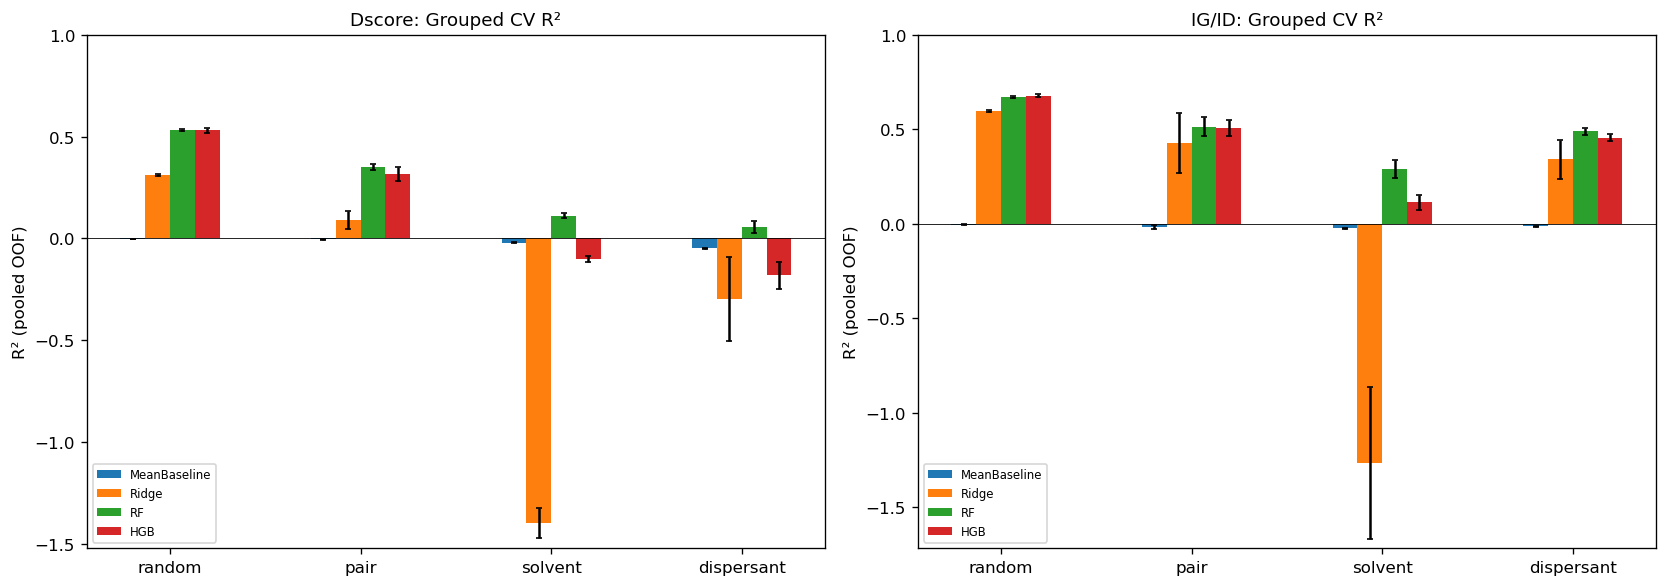

Negative R² means held-out predictions performed worse than the R² reference baseline; these values are not clipped or discarded.
Large drops from random to solvent/dispersant hold-out indicate limited chemical generalization.


In [15]:
if DATA_AVAILABLE:
    # Grouped bar chart with error bars
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, target, sumdf in zip(axes, ["Dscore", "IG/ID"], [sum_d, sum_i]):
        schemes = ["random", "pair", "solvent", "dispersant"]
        model_order = [m for m in ["MeanBaseline", "Ridge", "RF", "HGB", "XGB", "LGBM"] if m in sumdf["model"].values]
        x = np.arange(len(schemes))
        width = 0.13
        plot_lower_bounds = []
        for i, m in enumerate(model_order):
            vals, errs = [], []
            for s in schemes:
                row = sumdf[(sumdf["scheme"] == s) & (sumdf["model"] == m)]
                if len(row):
                    value = row["R2_mean"].values[0]
                    error = row["R2_std"].values[0] if np.isfinite(row["R2_std"].values[0]) else 0
                    vals.append(value)
                    errs.append(error)
                    if np.isfinite(value):
                        plot_lower_bounds.append(value - error)
                else:
                    vals.append(np.nan); errs.append(0)
            ax.bar(x + i * width, vals, width, yerr=errs, label=m, capsize=2)
        ax.set_xticks(x + width * (len(model_order) - 1) / 2)
        ax.set_xticklabels(schemes)
        ax.set_ylabel("R² (pooled OOF)")
        ax.set_title(f"{target}: Grouped CV R²")
        ax.axhline(0, color="k", lw=0.5)
        ax.legend(loc="lower left", fontsize=7)
        lower_limit = min(-0.05, min(plot_lower_bounds) - 0.05) if plot_lower_bounds else -0.5
        ax.set_ylim(lower_limit, 1.0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_grouped_cv_r2.png", bbox_inches="tight")
    plt.show()

    print("Negative R² means held-out predictions performed worse than the R² reference baseline; these values are not clipped or discarded.")
    print("Large drops from random to solvent/dispersant hold-out indicate limited chemical generalization.")

## 5. Ablations

In [17]:
if DATA_AVAILABLE:
    FEATURE_GROUPS = {
        "process": ["log10_RME", "log10_sonic", "rpm_max", "RME_total", "sonic_total"] + CAT_COLS,
        "composition": COMP_COLS + CAT_COLS,
        "dispersant_desc": [c for c in MOL_D if c in train_prep.columns] + CAT_COLS,
        "solvent_desc": [c for c in MOL_S if c in train_prep.columns] + CAT_COLS,
        "similarity": [c for c in SIM_COLS if c in train_prep.columns] + ["is_water"] + CAT_COLS,
        "experimental": COMP_COLS + ["log10_RME", "log10_sonic", "rpm_max"] + CAT_COLS,
        "exp+similarity": COMP_COLS + ["log10_RME", "log10_sonic", "rpm_max", "is_water"] +
                          [c for c in SIM_COLS if c in train_prep.columns] + CAT_COLS,
        "all": feat_cols + CAT_COLS,
    }

    def ablation_cv(X_full, y, groups, feature_groups, model_name="RF", n_splits=5, seed=SEED):
        models = get_models(seed)
        est, scale = models[model_name]
        rows = []
        for gname, cols in feature_groups.items():
            cols_present = [c for c in cols if c in X_full.columns]
            if len(cols_present) < 2:
                continue
            Xsub = X_full[cols_present]
            oof, fold_mets = run_grouped_cv(Xsub, y, groups, est, scale, n_splits=n_splits, seed=seed)
            overall = pooled_oof_metrics(y, oof)
            rows.append({"group": gname, "n_features": len(cols_present), **overall})
        return pd.DataFrame(rows)

    print("=== ABLATIONS on held-out dispersants (RF) ===")
    abl_disp_d = ablation_cv(X_d, y_d, g_disp_d, FEATURE_GROUPS, "RF")
    abl_disp_i = ablation_cv(X_i, y_i, g_disp_i, FEATURE_GROUPS, "RF")
    print("\nDscore (held-out dispersant):")
    print(abl_disp_d.sort_values("R2", ascending=False).to_string(index=False))
    print("\nIG/ID (held-out dispersant):")
    print(abl_disp_i.sort_values("R2", ascending=False).to_string(index=False))

    print("\n=== ABLATIONS on held-out solvents (RF) ===")
    abl_solv_d = ablation_cv(X_d, y_d, g_solv_d, FEATURE_GROUPS, "RF")
    abl_solv_i = ablation_cv(X_i, y_i, g_solv_i, FEATURE_GROUPS, "RF")
    print("\nDscore (held-out solvent):")
    print(abl_solv_d.sort_values("R2", ascending=False).to_string(index=False))
    print("\nIG/ID (held-out solvent):")
    print(abl_solv_i.sort_values("R2", ascending=False).to_string(index=False))

    proc_r2 = abl_disp_i.loc[abl_disp_i["group"] == "process", "R2"].values
    full_r2 = abl_disp_i.loc[abl_disp_i["group"] == "all", "R2"].values
    if len(proc_r2) and len(full_r2):
        print(
            f"\nHeld-out-dispersant IG/ID ablation: process-only features R²={proc_r2[0]:.3f}; "
            f"full feature set R²={full_r2[0]:.3f}. Process-only features retained predictive performance, "
            "while the full feature set provided additional predictive information."
        )

    abl_disp_d.to_csv(OUT_DIR / "ablation_disp_dscore.csv", index=False)
    abl_disp_i.to_csv(OUT_DIR / "ablation_disp_igid.csv", index=False)

=== ABLATIONS on held-out dispersants (RF) ===

Dscore (held-out dispersant):
          group  n_features        R2      MAE     RMSE   n
            all          39  0.022706 0.128695 0.158710 666
        process           7 -0.016296 0.124984 0.161846 666
 exp+similarity          12 -0.040147 0.127318 0.163734 666
   solvent_desc          15 -0.046438 0.130062 0.164229 666
dispersant_desc          14 -0.121077 0.137106 0.169985 666
    composition           4 -0.140984 0.133253 0.171487 666
     similarity           7 -0.151753 0.136225 0.172295 666
   experimental           7 -0.208320 0.133183 0.176475 666

IG/ID (held-out dispersant):
          group  n_features       R2       MAE      RMSE   n
   solvent_desc          15 0.540034 13.450800 17.835783 496
            all          39 0.513168 13.796531 18.349262 496
        process           7 0.420682 15.211671 20.016484 496
    composition           4 0.401814 15.610817 20.339833 496
   experimental           7 0.399750 15.615080 

In [18]:
if DATA_AVAILABLE:
    # Engineered vs paper-slot features (test claim of no gain)
    print("=== Engineered features test (held-out dispersant, RF) ===")
    paper_slot = COMP_COLS + MOL_D + MOL_S + SIM_COLS + CAT_COLS  # without engineered energy logs
    paper_slot = [c for c in paper_slot if c in X_d.columns]
    eng_all = feat_cols + CAT_COLS

    for label, cols in [("paper_slot", paper_slot), ("+engineered", eng_all)]:
        Xsub = X_d[[c for c in cols if c in X_d.columns]]
        oof, _ = run_grouped_cv(Xsub, y_d, g_disp_d, get_models()["RF"][0], False, n_splits=5)
        m = pooled_oof_metrics(y_d, oof)
        print(f"  Dscore {label:15s}: R2={m['R2']:.3f} MAE={m['MAE']:.3f}")

    for label, cols in [("paper_slot", paper_slot), ("+engineered", eng_all)]:
        Xsub = X_i[[c for c in cols if c in X_i.columns]]
        oof, _ = run_grouped_cv(Xsub, y_i, g_disp_i, get_models()["RF"][0], False, n_splits=5)
        m = pooled_oof_metrics(y_i, oof)
        print(f"  IG/ID  {label:15s}: R2={m['R2']:.3f} MAE={m['MAE']:.3f}")


=== Engineered features test (held-out dispersant, RF) ===
  Dscore paper_slot     : R2=-0.009 MAE=0.132
  Dscore +engineered    : R2=0.023 MAE=0.129
  IG/ID  paper_slot     : R2=0.486 MAE=13.858
  IG/ID  +engineered    : R2=0.513 MAE=13.797


## 6. Grouped Permutation Importance

Permutation importance (held-out dispersant folds, RF)...

Dscore ΔMAE when group permuted:
          group  delta_MAE_mean  delta_MAE_std  n_folds
dispersant_desc        0.014103       0.008267        5
        process        0.004817       0.004098        5
     similarity        0.004563       0.002524        5
   solvent_desc        0.002031       0.003248        5
    composition        0.000334       0.001498        5

IG/ID ΔMAE when group permuted:
          group  delta_MAE_mean  delta_MAE_std  n_folds
        process        8.270968       2.190764        5
   solvent_desc        2.965003       1.616125        5
     similarity        0.195962       0.206595        5
    composition        0.064386       0.175747        5
dispersant_desc       -0.526379       0.819718        5

NOTE: DoE confounding (process levels entangled with composition) limits causal interpretation.


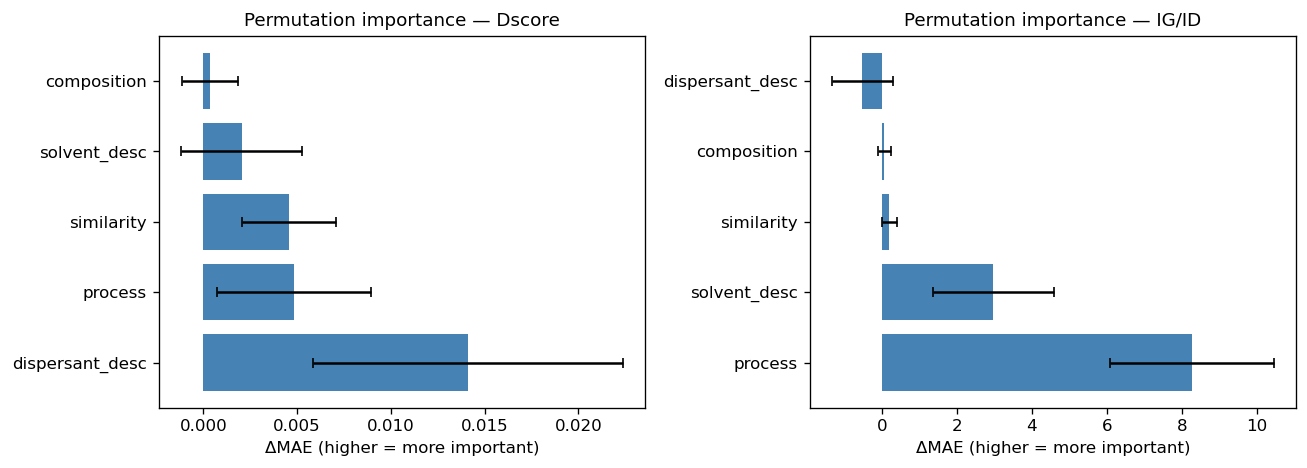

In [33]:
if DATA_AVAILABLE:
    def grouped_permutation_importance(
        X, y, groups, feature_group_map: Dict[str, List[str]],
        model_name="RF", n_splits=5, n_repeats=5, seed=SEED
    ) -> pd.DataFrame:
        """Permutation importance aggregated by feature groups on held-out GroupKFold folds."""
        est, scale = get_models(seed)[model_name]
        g = groups.loc[X.index]
        n_splits = min(n_splits, g.nunique())
        gkf = GroupKFold(n_splits=n_splits)
        group_names = list(feature_group_map.keys())
        importances = {gn: [] for gn in group_names}

        for tr, te in gkf.split(X, y, g):
            num_f = [c for c in X.columns if c not in CAT_COLS]
            cat_f = [c for c in CAT_COLS if c in X.columns]
            pipe = make_pipeline(clone(est), num_f, cat_f, scale=scale)
            pipe.fit(X.iloc[tr], y.iloc[tr])
            baseline = mean_absolute_error(y.iloc[te], pipe.predict(X.iloc[te]))

            for gn, cols in feature_group_map.items():
                cols_in = [c for c in cols if c in X.columns]
                if not cols_in:
                    continue
                deltas = []
                for _ in range(n_repeats):
                    Xperm = X.iloc[te].copy()
                    for c in cols_in:
                        Xperm[c] = np.random.permutation(Xperm[c].values)
                    mae_perm = mean_absolute_error(y.iloc[te], pipe.predict(Xperm))
                    deltas.append(mae_perm - baseline)
                importances[gn].append(np.mean(deltas))

        rows = []
        for gn, vals in importances.items():
            rows.append({
                "group": gn,
                "delta_MAE_mean": np.mean(vals) if vals else np.nan,
                "delta_MAE_std": np.std(vals) if vals else np.nan,
                "n_folds": len(vals),
            })
        return pd.DataFrame(rows).sort_values("delta_MAE_mean", ascending=False)


    perm_groups = {
        "process": ["log10_RME", "log10_sonic", "rpm_max", "RME_total", "sonic_total", "process_sequence"],
        "composition": COMP_COLS + ["carbon"],
        "dispersant_desc": [c for c in MOL_D if c in X_d.columns],
        "solvent_desc": [c for c in MOL_S if c in X_d.columns],
        "similarity": [c for c in SIM_COLS if c in X_d.columns] + ["is_water"],
    }

    print("Permutation importance (held-out dispersant folds, RF)...")
    pi_d = grouped_permutation_importance(X_d, y_d, g_disp_d, perm_groups, "RF", n_splits=5, n_repeats=3)
    pi_i = grouped_permutation_importance(X_i, y_i, g_disp_i, perm_groups, "RF", n_splits=5, n_repeats=3)

    print("\nDscore ΔMAE when group permuted:")
    print(pi_d.to_string(index=False))
    print("\nIG/ID ΔMAE when group permuted:")
    print(pi_i.to_string(index=False))
    print("\nNOTE: DoE confounding (process levels entangled with composition) limits causal interpretation.")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, pi, title in zip(axes, [pi_d, pi_i], ["Dscore", "IG/ID"]):
        ax.barh(pi["group"], pi["delta_MAE_mean"], xerr=pi["delta_MAE_std"], color="steelblue", capsize=3)
        ax.set_xlabel("ΔMAE (higher = more important)")
        ax.set_title(f"Permutation importance — {title}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04_permutation_importance.png", bbox_inches="tight")
    plt.show()

    pi_d.to_csv(OUT_DIR / "perm_imp_dscore.csv", index=False)
    pi_i.to_csv(OUT_DIR / "perm_imp_igid.csv", index=False)


## 7. External Validation on SI-004

In [19]:
if DATA_AVAILABLE:
    # Split validation sets
    # Align categoly from original df_val
    val_prep = val_prep.copy()
    val_prep["categoly"] = df_val["categoly"].values

    val_extra = val_prep[val_prep["categoly"] == "extrapolative test"].copy()
    val_interp = val_prep[val_prep["categoly"] == "interpolation test"].copy()

    # Fix process_sequence for extrapolative
    val_extra["process_sequence"] = val_extra["process_sequence"].fillna("Bath")
    val_interp["process_sequence"] = val_interp["process_sequence"].fillna("Bath")

    print(f"Extrapolative rows: {len(val_extra)}")
    print(f"Interpolation rows: {len(val_interp)}")
    print(f"Extrapolative dispersants: {val_extra['dispersant'].unique().tolist()}")

    # Train final models on ALL training data
    print("\nTraining final surrogates on full si_003...")
    num_f = [c for c in feat_cols if c in train_prep.columns and c not in CAT_COLS]
    cat_f = CAT_COLS

    final_rf_d = make_pipeline(
        RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=SEED, n_jobs=-1),
        num_f, cat_f, scale=False
    )
    final_rf_i = make_pipeline(
        RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=SEED, n_jobs=-1),
        num_f, cat_f, scale=False
    )

    X_train_d = train_prep.loc[mask_d, num_f + cat_f]
    X_train_i = train_prep.loc[mask_i, num_f + cat_f]
    final_rf_d.fit(X_train_d, y_dscore.loc[mask_d])
    final_rf_i.fit(X_train_i, y_igid.loc[mask_i])

    # Also train HGB ensemble members
    final_hgb_d = make_pipeline(
        HistGradientBoostingRegressor(max_iter=300, max_depth=8, learning_rate=0.05, random_state=SEED),
        num_f, cat_f, scale=False
    )
    final_hgb_i = make_pipeline(
        HistGradientBoostingRegressor(max_iter=300, max_depth=8, learning_rate=0.05, random_state=SEED),
        num_f, cat_f, scale=False
    )
    final_hgb_d.fit(X_train_d, y_dscore.loc[mask_d])
    final_hgb_i.fit(X_train_i, y_igid.loc[mask_i])
    print("Done.")


Extrapolative rows: 56
Interpolation rows: 9
Extrapolative dispersants: ['Amsonic acid', 'NY18', 'TDOC', 'Stilbazo']

Training final surrogates on full si_003...
Done.


=== EXTRAPOLATIVE (56 rows, 4 new dispersants) ===
Dscore MAE model=0.130  baseline=0.263  R2=0.253
  (paper reported R2≈0.31 MAE≈0.12 for their XGB; our numbers may differ)
  NOTE: n=4 dispersants → R2 is fragile; report qualitatively.
  Bootstrap R2 (by dispersant): median=0.253  95% CI=[-0.877, 0.493]


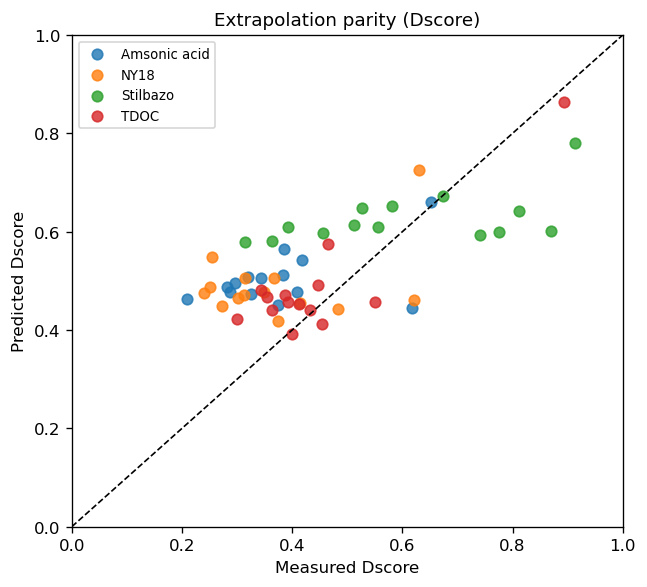

  Threshold Dscore≥0.8: precision=1.00 recall=0.25  (TP=1 FP=0 FN=3  positives=4)
  Threshold Dscore≥0.6: precision=0.58 recall=0.64  (TP=7 FP=5 FN=4  positives=11)

IG/ID on 25 measurable extrapolative rows:
  MAE model=10.70  baseline=9.30  R2=-0.278


In [20]:
if DATA_AVAILABLE:
    # --- Extrapolative validation ---
    Xe = val_extra[num_f + cat_f].copy()
    for c in num_f + cat_f:
        if c not in Xe.columns:
            Xe[c] = 0 if c not in cat_f else "Bath"

    pred_d_e = 0.5 * (final_rf_d.predict(Xe) + final_hgb_d.predict(Xe))
    y_d_e = val_extra["Dscore"].values if "Dscore" in val_extra.columns else df_val.loc[df_val["categoly"]=="extrapolative test", "Dscore"].values

    mean_baseline_d = y_dscore.loc[mask_d].mean()
    mae_model = mean_absolute_error(y_d_e, pred_d_e)
    mae_base = mean_absolute_error(y_d_e, np.full_like(y_d_e, mean_baseline_d))
    r2_e = r2_score(y_d_e, pred_d_e)

    print("=== EXTRAPOLATIVE (56 rows, 4 new dispersants) ===")
    print(f"Dscore MAE model={mae_model:.3f}  baseline={mae_base:.3f}  R2={r2_e:.3f}")
    print(f"  (paper reported R2≈0.31 MAE≈0.12 for their XGB; our numbers may differ)")
    print("  NOTE: n=4 dispersants → R2 is fragile; report qualitatively.")

    # Bootstrap whole dispersant clusters; repeated draws contribute repeated rows.
    disp_e = val_extra["dispersant"].values
    unique_disps = np.unique(disp_e)
    cluster_rows = {dname: np.flatnonzero(disp_e == dname) for dname in unique_disps}
    rng = np.random.RandomState(SEED)
    boot_r2 = []
    for _ in range(500):
        sampled = rng.choice(unique_disps, size=len(unique_disps), replace=True)
        sampled_rows = np.concatenate([cluster_rows[dname] for dname in sampled])
        y_boot = y_d_e[sampled_rows]
        pred_boot = pred_d_e[sampled_rows]
        finite = np.isfinite(y_boot) & np.isfinite(pred_boot)
        if finite.sum() < 5 or np.unique(y_boot[finite]).size < 2:
            continue
        boot_r2.append(r2_score(y_boot[finite], pred_boot[finite]))
    if boot_r2:
        print(f"  Bootstrap R2 (by dispersant): median={np.median(boot_r2):.3f}  "
              f"95% CI=[{np.percentile(boot_r2, 2.5):.3f}, {np.percentile(boot_r2, 97.5):.3f}]")

    # Parity by dispersant
    fig, ax = plt.subplots(figsize=(5.5, 5))
    for dname in unique_disps:
        m = disp_e == dname
        ax.scatter(y_d_e[m], pred_d_e[m], label=dname, s=40, alpha=0.8)
    lims = [0, 1]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("Measured Dscore"); ax.set_ylabel("Predicted Dscore")
    ax.set_title("Extrapolation parity (Dscore)")
    ax.legend(fontsize=8); ax.set_xlim(lims); ax.set_ylim(lims)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_extrapolation_parity_dscore.png", bbox_inches="tight")
    plt.show()

    # Binary screening
    for thr in [0.8, 0.6]:
        y_bin = (y_d_e >= thr).astype(int)
        p_bin = (pred_d_e >= thr).astype(int)
        tp = ((y_bin == 1) & (p_bin == 1)).sum()
        fp = ((y_bin == 0) & (p_bin == 1)).sum()
        fn = ((y_bin == 1) & (p_bin == 0)).sum()
        prec = tp / (tp + fp) if (tp + fp) else np.nan
        rec = tp / (tp + fn) if (tp + fn) else np.nan
        print(f"  Threshold Dscore≥{thr}: precision={prec:.2f} recall={rec:.2f}  (TP={tp} FP={fp} FN={fn}  positives={y_bin.sum()})")

    # IG/ID on measurable extrapolative rows
    y_i_e = val_extra["IG/ID"].values if "IG/ID" in val_extra.columns else df_val.loc[df_val["categoly"]=="extrapolative test", "IG/ID"].values
    mask_ie = np.isfinite(y_i_e)
    if mask_ie.sum() > 0:
        pred_i_e = 0.5 * (final_rf_i.predict(Xe) + final_hgb_i.predict(Xe))
        print(f"\nIG/ID on {mask_ie.sum()} measurable extrapolative rows:")
        print(f"  MAE model={mean_absolute_error(y_i_e[mask_ie], pred_i_e[mask_ie]):.2f}  "
              f"baseline={mean_absolute_error(y_i_e[mask_ie], np.full(mask_ie.sum(), y_igid.loc[mask_i].mean())):.2f}  "
              f"R2={r2_score(y_i_e[mask_ie], pred_i_e[mask_ie]):.3f}")
    else:
        print("No measurable IG/ID in extrapolative set.")

=== INTERPOLATION (9 rows, in-domain combinations) ===
Dscore: R2=0.602 MAE=0.055  (paper 0.64 / 0.06)
IG/ID:  R2=0.754 MAE=9.49  (paper 0.88 / 6.18)


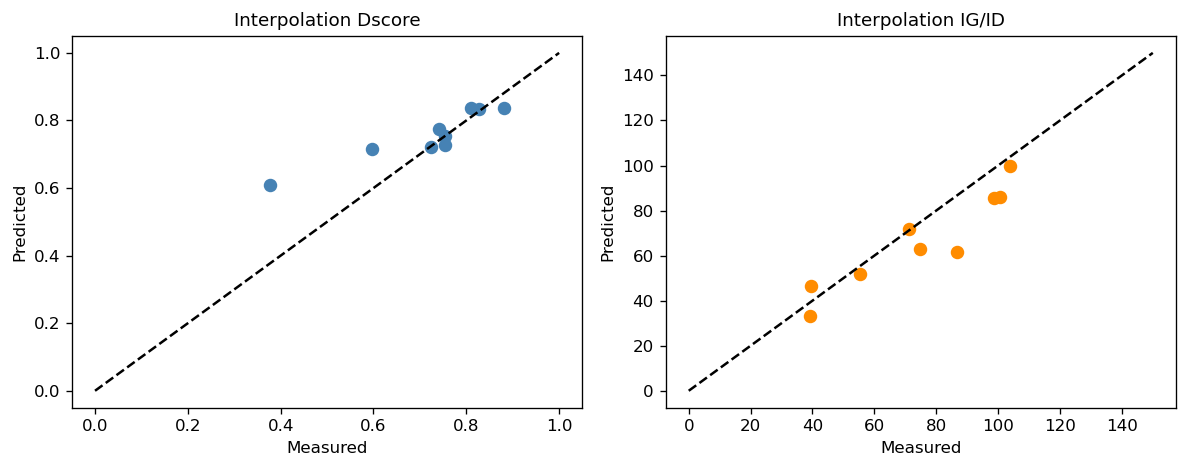

In [21]:
if DATA_AVAILABLE:
    # --- Interpolation validation (9 rows) ---
    Xi = val_interp[num_f + cat_f].copy()
    for c in num_f + cat_f:
        if c not in Xi.columns:
            Xi[c] = 0 if c not in cat_f else "Bath"

    y_d_i = val_interp["Dscore"].values if "Dscore" in val_interp.columns else df_val.loc[df_val["categoly"]=="interpolation test", "Dscore"].values
    y_i_i = val_interp["IG/ID"].values if "IG/ID" in val_interp.columns else df_val.loc[df_val["categoly"]=="interpolation test", "IG/ID"].values

    pred_d_i = 0.5 * (final_rf_d.predict(Xi) + final_hgb_d.predict(Xi))
    pred_i_i = 0.5 * (final_rf_i.predict(Xi) + final_hgb_i.predict(Xi))

    print("=== INTERPOLATION (9 rows, in-domain combinations) ===")
    print(f"Dscore: R2={r2_score(y_d_i, pred_d_i):.3f} MAE={mean_absolute_error(y_d_i, pred_d_i):.3f}  (paper 0.64 / 0.06)")
    mask_ii = np.isfinite(y_i_i)
    if mask_ii.sum():
        print(f"IG/ID:  R2={r2_score(y_i_i[mask_ii], pred_i_i[mask_ii]):.3f} MAE={mean_absolute_error(y_i_i[mask_ii], pred_i_i[mask_ii]):.2f}  (paper 0.88 / 6.18)")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(y_d_i, pred_d_i, s=50, c="steelblue")
    axes[0].plot([0, 1], [0, 1], "k--")
    axes[0].set_xlabel("Measured"); axes[0].set_ylabel("Predicted"); axes[0].set_title("Interpolation Dscore")
    if mask_ii.sum():
        axes[1].scatter(y_i_i[mask_ii], pred_i_i[mask_ii], s=50, c="darkorange")
        axes[1].plot([0, 150], [0, 150], "k--")
        axes[1].set_xlabel("Measured"); axes[1].set_ylabel("Predicted"); axes[1].set_title("Interpolation IG/ID")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "06_interpolation_parity.png", bbox_inches="tight")
    plt.show()
    PIPELINE_STAGES["external_validation"] = True

## 8. Uncertainty & Applicability Domain

Calibrating RF uncertainty proxies for both targets with grouped OOF...
Dscore RF spread/error correlation=0.358; 95th-percentile cap=0.159417
IG/ID RF spread/error correlation=0.333; 95th-percentile cap=21.433630


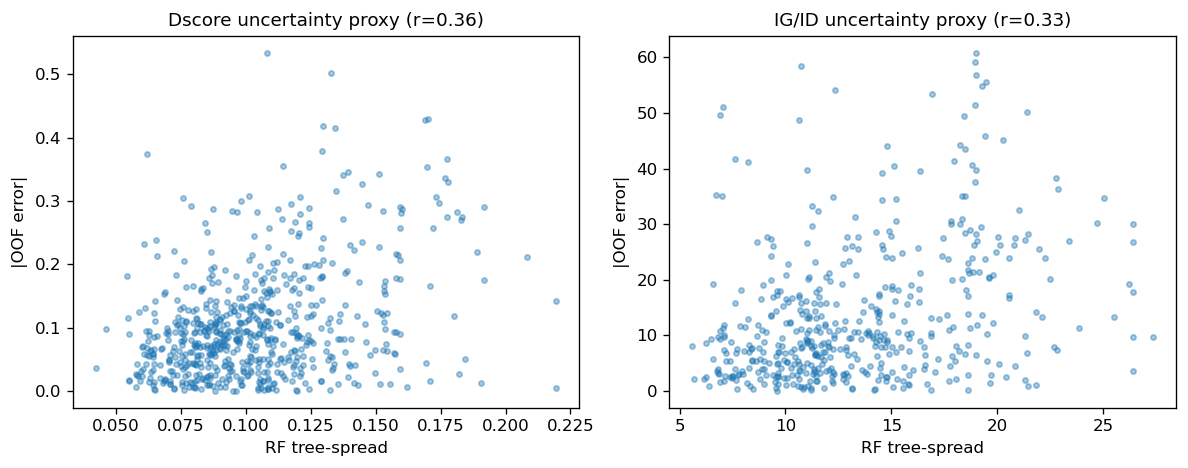

In [22]:
if DATA_AVAILABLE:
    def rf_tree_spread(pipe, X):
        """Std of predictions across trees in the fitted RF step."""
        Xt = pipe.named_steps["pre"].transform(X)
        rf = pipe.named_steps["model"]
        preds = np.array([tree.predict(Xt) for tree in rf.estimators_])
        return preds.std(axis=0)


    def grouped_rf_spread_oof(X, y, groups):
        gkf = GroupKFold(n_splits=5)
        spreads, abs_errors = [], []
        for tr, te in gkf.split(X, y, groups):
            pipe = make_pipeline(
                RandomForestRegressor(
                    n_estimators=300, max_depth=12, min_samples_leaf=3,
                    random_state=SEED, n_jobs=-1,
                ),
                num_f, cat_f, scale=False,
            )
            pipe.fit(X.iloc[tr], y.iloc[tr])
            pred = pipe.predict(X.iloc[te])
            spreads.extend(rf_tree_spread(pipe, X.iloc[te]))
            abs_errors.extend(np.abs(y.iloc[te].to_numpy() - pred))
        return np.asarray(spreads), np.asarray(abs_errors)


    print("Calibrating RF uncertainty proxies for both targets with grouped OOF...")
    spreads_d, abs_errs_d = grouped_rf_spread_oof(X_d, y_d, g_pair_d)
    spreads_i, abs_errs_i = grouped_rf_spread_oof(X_i, y_i, g_pair_i)
    corr_d = np.corrcoef(spreads_d, abs_errs_d)[0, 1] if len(spreads_d) > 5 else np.nan
    corr_i = np.corrcoef(spreads_i, abs_errs_i)[0, 1] if len(spreads_i) > 5 else np.nan
    tree_spread_cap_d = float(np.percentile(spreads_d[np.isfinite(spreads_d)], 95))
    tree_spread_cap_i = float(np.percentile(spreads_i[np.isfinite(spreads_i)], 95))
    print(f"Dscore RF spread/error correlation={corr_d:.3f}; 95th-percentile cap={tree_spread_cap_d:.6f}")
    print(f"IG/ID RF spread/error correlation={corr_i:.3f}; 95th-percentile cap={tree_spread_cap_i:.6f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, spread, error, target, corr in zip(
        axes, [spreads_d, spreads_i], [abs_errs_d, abs_errs_i],
        ["Dscore", "IG/ID"], [corr_d, corr_i],
    ):
        ax.scatter(spread, error, s=10, alpha=0.4)
        ax.set_xlabel("RF tree-spread"); ax.set_ylabel("|OOF error|")
        ax.set_title(f"{target} uncertainty proxy (r={corr:.2f})")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_uncertainty_vs_error.png", bbox_inches="tight")
    plt.show()
    PIPELINE_STAGES["applicability_domain"] = False

Building kNN applicability domain...
AD features (30 numeric; categorical features omitted): ['ESOL_LogS_D', 'EState_VSA2_D', 'EState_VSA4_D', 'EState_VSA5_D', 'HallKierAlpha_D', 'Kappa3_D', 'MaxEStateIndex_D', 'MinAbsEStateIndex_D', 'MinEStateIndex_D', 'PEOE_VSA6_D', 'VSA_EState5_D', 'VSA_EState8_D', 'BCUT2D_LOGPHI_S', 'BCUT2D_MRHI_S', 'BCUT2D_MRLOW_S', 'BCUT2D_MWHI_S', 'Chi1_S', 'Chi2n_S', 'FpDensityMorgan3_S', 'Kappa2_S', 'Kappa3_S', 'MinAbsEStateIndex_S', 'MolLogP_S', 'MolMR_S', 'VSA_EState8_S', 'wt%', 'Disp/Carbon', 'log10_RME', 'log10_sonic', 'rpm_max']
AD threshold (95th percentile training kNN distance) = 3.758

Extrapolative samples relative to AD:
  Amsonic acid         mean distance=2.209; outside=0/14 (0.0%)
  NY18                 mean distance=2.431; outside=0/14 (0.0%)
  Stilbazo             mean distance=2.343; outside=0/14 (0.0%)
  TDOC                 mean distance=1.700; outside=0/14 (0.0%)


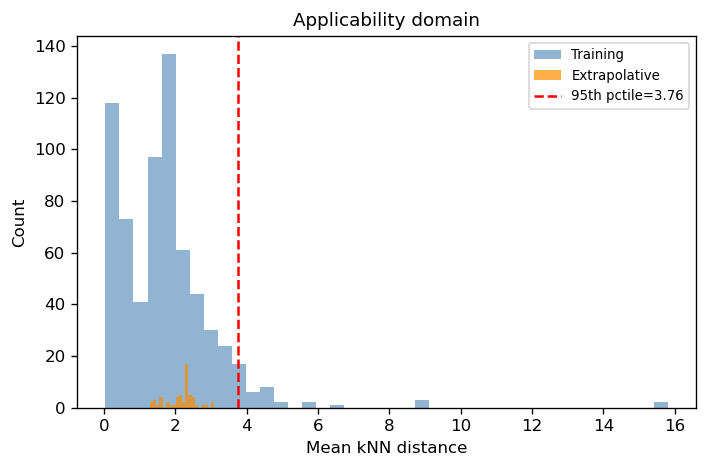

In [23]:
if DATA_AVAILABLE:
    print("Building kNN applicability domain...")
    ad_feature_candidates = list(dict.fromkeys(
        MOL_D + MOL_S + COMP_COLS + ["log10_RME", "log10_sonic", "rpm_max"]
    ))
    num_for_ad = [c for c in ad_feature_candidates if c in X_train_d.columns]
    if not num_for_ad:
        raise RuntimeError("No selected numeric features are available for the AD metric.")
    Xad = X_train_d[num_for_ad].fillna(0).values
    scaler_ad = StandardScaler()
    Xad_s = scaler_ad.fit_transform(Xad)

    knn = NearestNeighbors(n_neighbors=6, metric="euclidean")
    knn.fit(Xad_s)
    dists, _ = knn.kneighbors(Xad_s)
    mean_nn_dist = dists[:, 1:].mean(axis=1)
    ad_threshold = np.percentile(mean_nn_dist, 95)
    print(f"AD features ({len(num_for_ad)} numeric; categorical features omitted): {num_for_ad}")
    print(f"AD threshold (95th percentile training kNN distance) = {ad_threshold:.3f}")

    Xe_ad = Xe[num_for_ad].fillna(0).values
    Xe_ad_s = scaler_ad.transform(Xe_ad)
    dists_e, _ = knn.kneighbors(Xe_ad_s)
    mean_nn_e = dists_e[:, :5].mean(axis=1)

    print("\nExtrapolative samples relative to AD:")
    for dname in unique_disps:
        group_mask = disp_e == dname
        group_distances = mean_nn_e[group_mask]
        outside_count = int(np.count_nonzero(group_distances > ad_threshold))
        sample_count = int(group_mask.sum())
        outside_fraction = outside_count / sample_count if sample_count else np.nan
        print(
            f"  {dname:20s} mean distance={group_distances.mean():.3f}; "
            f"outside={outside_count}/{sample_count} ({outside_fraction:.1%})"
        )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(mean_nn_dist, bins=40, alpha=0.6, label="Training", color="steelblue")
    ax.hist(mean_nn_e, bins=20, alpha=0.7, label="Extrapolative", color="darkorange")
    ax.axvline(ad_threshold, color="red", ls="--", label=f"95th pctile={ad_threshold:.2f}")
    ax.set_xlabel("Mean kNN distance")
    ax.set_ylabel("Count")
    ax.set_title("Applicability domain")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "08_applicability_domain.png", bbox_inches="tight")
    plt.show()
    PIPELINE_STAGES["applicability_domain"] = True

## 9. Design-Space Enumeration

In [24]:
if DATA_AVAILABLE:
    pair_table = train_prep.groupby(["dispersant", "solvent"], as_index=False).agg(
        {c: "median" for c in num_f if c in train_prep.columns}
    )
    print("Observed chemistry pairs:", len(pair_table))
    check("Search retains observed chemistry pairs", len(pair_table) == facts["n_pairs"])

    design_keys = ["dispersant", "solvent", "process_sequence"]
    observed_design_combos = set(map(tuple, train_prep[design_keys].drop_duplicates().to_numpy()))
    design_table = train_prep.groupby(design_keys, as_index=False).agg(
        {c: "median" for c in num_f if c in train_prep.columns}
    )
    design_table["design_idx"] = np.arange(len(design_table))
    design_combos = set(map(tuple, design_table[design_keys].to_numpy()))
    if design_combos != observed_design_combos:
        raise RuntimeError("Design table does not exactly match observed chemistry-process triples.")
    print("Observed chemistry-process designs:", len(design_table))

    seq_bounds = {}
    for ps, g in train_prep.groupby("process_sequence"):
        seq_bounds[ps] = {
            "wt%": (g["wt%"].min(), g["wt%"].max()),
            "Disp/Carbon": (g["Disp/Carbon"].min(), g["Disp/Carbon"].max()),
            "log10_RME": (g["log10_RME"].min(), g["log10_RME"].max()),
            "log10_sonic": (g["log10_sonic"].min(), g["log10_sonic"].max()),
            "rpm_max": (g["rpm_max"].min(), g["rpm_max"].max()),
        }
    PROC_SEQS = list(seq_bounds)
    CNT_TYPES = sorted(train_prep.carbon.dropna().astype(str).unique())
    rows = []
    for _, design in design_table.iterrows():
        ps = design["process_sequence"]
        bounds = seq_bounds[ps]
        wt_values = np.linspace(*bounds["wt%"], 3) if bounds["wt%"][1] > bounds["wt%"][0] else [bounds["wt%"][0]]
        dc_values = np.linspace(*bounds["Disp/Carbon"], 4) if bounds["Disp/Carbon"][1] > bounds["Disp/Carbon"][0] else [bounds["Disp/Carbon"][0]]
        rme_values = np.linspace(*bounds["log10_RME"], 4) if bounds["log10_RME"][1] > bounds["log10_RME"][0] else [bounds["log10_RME"][0]]
        sonic_values = np.linspace(*bounds["log10_sonic"], 4) if bounds["log10_sonic"][1] > bounds["log10_sonic"][0] else [bounds["log10_sonic"][0]]
        for carbon in CNT_TYPES:
            for wt in wt_values:
                for dc in dc_values:
                    for lr in rme_values:
                        for ls in sonic_values:
                            row = {c: design.get(c, 0) for c in num_f}
                            row.update({
                                "wt%": wt,
                                "Disp/Carbon": dc,
                                "log10_RME": lr,
                                "log10_sonic": ls,
                                "RME_total": 10 ** lr - 1 if np.isfinite(lr) else 0,
                                "sonic_total": 10 ** ls - 1 if np.isfinite(ls) else 0,
                                "rpm_max": bounds["rpm_max"][1],
                                "carbon": carbon,
                                "process_sequence": ps,
                                "dispersant": design["dispersant"],
                                "solvent": design["solvent"],
                                "design_idx": int(design["design_idx"]),
                            })
                            rows.append(row)

    enum_df = pd.DataFrame(rows)
    print("Enumerated candidates:", len(enum_df))
    Xe_enum = enum_df[num_f + cat_f]
    enum_df["pred_Dscore"] = .5 * (final_rf_d.predict(Xe_enum) + final_hgb_d.predict(Xe_enum))
    enum_df["pred_IGID"] = .5 * (final_rf_i.predict(Xe_enum) + final_hgb_i.predict(Xe_enum))
    enum_df["tree_spread_d"] = rf_tree_spread(final_rf_d, Xe_enum)
    enum_df["tree_spread_i"] = rf_tree_spread(final_rf_i, Xe_enum)
    ad_enum = scaler_ad.transform(Xe_enum[num_for_ad].fillna(0))
    nn, _ = knn.kneighbors(ad_enum)
    enum_df["knn_dist"] = nn[:, :5].mean(axis=1)

    enum_combos = set(map(tuple, enum_df[design_keys].drop_duplicates().to_numpy()))
    n_unobserved = sum(combo not in observed_design_combos for combo in enum_combos)
    print(f"Unique chemistry-process designs in enumeration: {len(enum_combos)}, unobserved: {n_unobserved}")
    if n_unobserved:
        raise RuntimeError("Enumeration contains unobserved chemistry-process combinations.")
    print("CNT, RME, and sonication remain independent choices; RPM is fixed at the observed process maximum.")
    PIPELINE_STAGES["enumeration"] = True

Observed chemistry pairs: 289
[PASS] Search retains observed chemistry pairs
Observed chemistry-process designs: 347
Enumerated candidates: 36640
Unique chemistry-process designs in enumeration: 347, unobserved: 0
CNT, RME, and sonication remain independent choices; RPM is fixed at the observed process maximum.


Enumeration feasible candidates: 9,687 / 36,640 (26.4%)
Constrained enumerated grid Pareto front size: 35


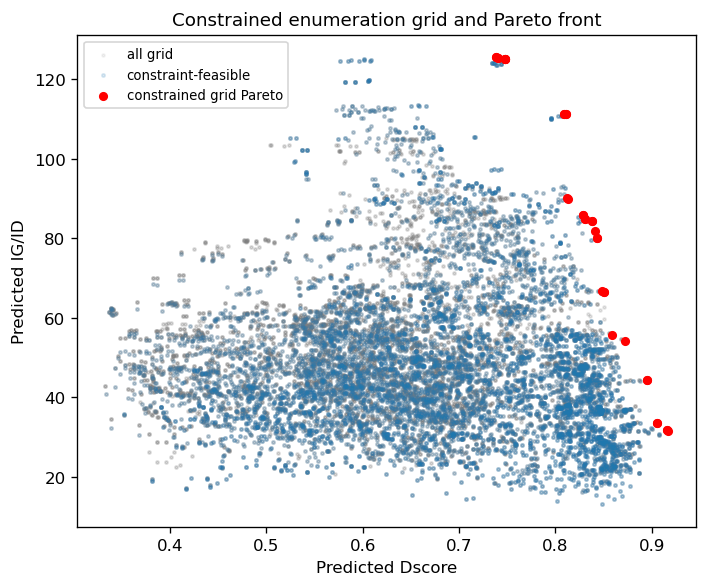

Unique chemistry-process designs in enumeration: 347, unobserved: 0


In [25]:
if DATA_AVAILABLE:
    if "ad_threshold" not in globals() or "tree_spread_cap_d" not in globals() or "tree_spread_cap_i" not in globals():
        raise RuntimeError("AD/uncertainty thresholds are unavailable; run their calibration cells first.")

    enum_df["constraint_knn"] = enum_df["knn_dist"] - ad_threshold
    enum_df["constraint_tree_spread_d"] = enum_df["tree_spread_d"] - tree_spread_cap_d
    enum_df["constraint_tree_spread_i"] = enum_df["tree_spread_i"] - tree_spread_cap_i
    enum_df["feasible"] = (
        np.isfinite(enum_df["constraint_knn"]) &
        np.isfinite(enum_df["constraint_tree_spread_d"]) &
        np.isfinite(enum_df["constraint_tree_spread_i"]) &
        (enum_df["constraint_knn"] <= 0) &
        (enum_df["constraint_tree_spread_d"] <= 0) &
        (enum_df["constraint_tree_spread_i"] <= 0)
    )

    feasible_enum = enum_df.loc[enum_df["feasible"]].copy()
    print(f"Enumeration feasible candidates: {len(feasible_enum):,} / {len(enum_df):,} "
          f"({len(feasible_enum)/len(enum_df):.1%})")
    if len(feasible_enum) == 0:
        raise RuntimeError("No enumerated candidates satisfy all applicability and uncertainty constraints.")

    if HAS_PYMOO:
        objs = np.column_stack([
            -feasible_enum["pred_Dscore"].values,
            -feasible_enum["pred_IGID"].values
        ])
        pareto_idx = NonDominatedSorting().do(objs)[0]
        pareto_enum = feasible_enum.iloc[pareto_idx].copy()
    else:
        def simple_pareto(df, c1, c2):
            d = df.sort_values(c1, ascending=False)
            keep = []
            best_c2 = -np.inf
            for i, row in d.iterrows():
                if row[c2] > best_c2:
                    keep.append(i)
                    best_c2 = row[c2]
            return df.loc[keep]
        pareto_enum = simple_pareto(feasible_enum, "pred_Dscore", "pred_IGID")

    print(f"Constrained enumerated grid Pareto front size: {len(pareto_enum)}")

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(enum_df["pred_Dscore"], enum_df["pred_IGID"], s=3, alpha=0.10,
               c="gray", label="all grid")
    ax.scatter(feasible_enum["pred_Dscore"], feasible_enum["pred_IGID"], s=4, alpha=0.15,
               c="tab:blue", label="constraint-feasible")
    ax.scatter(pareto_enum["pred_Dscore"], pareto_enum["pred_IGID"], s=20,
               c="red", label="constrained grid Pareto")
    ax.set_xlabel("Predicted Dscore")
    ax.set_ylabel("Predicted IG/ID")
    ax.set_title("Constrained enumeration grid and Pareto front")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "09_constrained_enumeration_pareto.png", bbox_inches="tight")
    plt.show()

    enum_combos = set(map(tuple, enum_df[design_keys].drop_duplicates().to_numpy()))
    n_unobserved = sum(combo not in observed_design_combos for combo in enum_combos)
    print(f"Unique chemistry-process designs in enumeration: {len(enum_combos)}, unobserved: {n_unobserved}")
    if n_unobserved != 0:
        raise RuntimeError("Constrained enumeration contains an unobserved chemistry-process combination.")
    PIPELINE_STAGES["constrained_front"] = True

## 10. Methodological Correction Audit

The search is restricted to experimentally observed dispersant–solvent–process triples. CNT type and the continuous formulation/process variables remain separate choices; a triple–CNT combination is not guaranteed to have been observed.

| Issue | Implemented behavior |
|---|---|
| Search design | Enumeration and NSGA-II select an observed chemistry–process `design_idx`; a structural check rejects unseen triples. |
| Applicability domain | Standardized kNN distance uses molecular descriptors, composition, log RME, log sonication, and rpm. It is numeric-only; categorical features are omitted. |
| Predictive uncertainty | Separate Dscore and IG/ID RF tree-spread caps are calibrated with pair-grouped OOF folds. Tree spread is an uncertainty proxy, not a calibrated interval. |
| RME vs sonication | Independent continuous genes map to `log10_RME` and `log10_sonic`; energies use the inverse `10**value - 1`. |
| Enumeration | The finite grid forms independent RME × sonication combinations within observed chemistry–process triples. RPM is fixed at the observed maximum for the selected process sequence. |
| NSGA-II sampling | Six variables are used: design index, CNT index, and four continuous formulation/process genes. |
| Hypervolume reference | NSGA-II and finite enumeration share objective and feasibility definitions. Hypervolume is only a comparison with the finite enumeration baseline, not a score or exact-front recovery metric. |

All Pareto candidates remain surrogate-model hypotheses requiring experimental validation.

## 10. NSGA-II (pymoo)

Setting up NSGA-II over observed chemistry-process designs...
NSGA-II done in 10.0s, final population=100
Feasible returned NSGA-II solutions: 100 / 100
Unique observed chemistry-process designs in NSGA-II: 5
Finite-grid comparison baseline: grid HV=16.6735  NSGA-II HV=17.6584  ratio=1.059
This compares a continuous optimizer with finite enumeration; it is not a score or exact-front recovery metric.


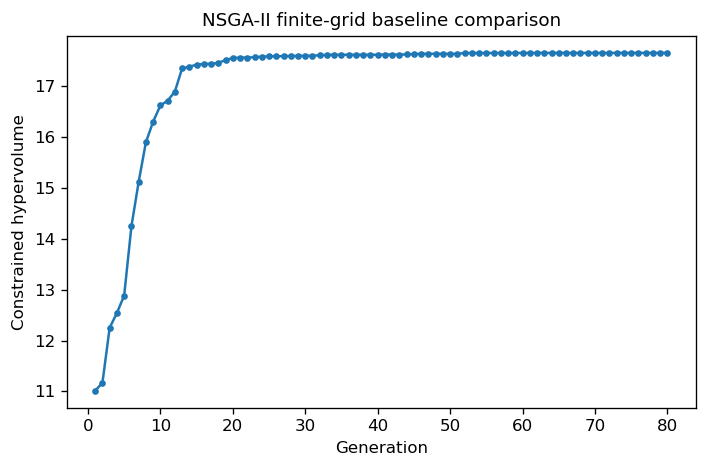

Final constrained NSGA-II Pareto size: 99


,wt%,Disp/Carbon,ESOL_LogS_D,EState_VSA2_D,EState_VSA4_D,EState_VSA5_D,HallKierAlpha_D,Kappa3_D,MaxEStateIndex_D,MinAbsEStateIndex_D,...,design_idx,pred_Dscore,pred_IGID,tree_spread_d,tree_spread_i,knn_dist,constraint_knn,constraint_tree_spread_d,constraint_tree_spread_i,feasible
0,0.064886,1.952156,0.0,9.790967,103.175298,58.330756,-6.50,37.261511,12.738368,0.317464,...,8,0.716989,125.992220,0.049498,16.969429,0.598493,-3.159685,-0.109919,-4.464200,True
1,0.065032,1.995351,0.0,9.790967,103.175298,58.330756,-6.50,37.261511,12.738368,0.317464,...,8,0.716989,125.992220,0.049498,16.969429,0.603254,-3.154924,-0.109919,-4.464200,True
2,0.136975,11.185973,0.0,167.301406,160.520541,0.000000,-0.84,24.928377,12.324619,0.005640,...,284,0.905407,33.499892,0.056456,7.921327,3.658397,-0.099781,-0.102961,-13.512302,True
3,0.155738,3.543985,0.0,9.790967,103.175298,58.330756,-6.50,37.261511,12.738368,0.317464,...,10,0.846010,79.964743,0.036769,8.443881,3.466977,-0.291202,-0.122648,-12.989748,True
4,0.119402,7.717284,0.0,167.301406,160.520541,0.000000,-0.84,24.928377,12.324619,0.005640,...,286,0.847278,60.241554,0.054889,18.040518,3.035877,-0.722301,-0.104528,-3.393111,True
5,0.099482,3.536873,0.0,9.790967,103.175298,58.330756,-6.50,37.261511,12.738368,0.317464,...,8,0.838099,101.441272,0.044455,14.838639,1.565019,-2.193160,-0.114962,-6.594990,True
6,0.098008,3.444062,0.0,9.790967,103.175298,58.330756,-6.50,37.261511,12.738368,0.317464,...,8,0.840471,97.844704,0.038928,15.184101,1.515886,-2.242293,-0.120489,-6.249528,True
7,0.024606,9.024340,0.0,9.790967,103.175298,58.330756,-6.50,37.261511,12.738368,0.317464,...,10,0.841259,81.755311,0.063437,9.341521,2.006064,-1.752114,-0.095980,-12.092108,True
8,0.065089,3.367170,0.0,9.790967,103.175298,58.330756,-6.50,37.261511,12.738368,0.317464,...,8,0.813159,108.409027,0.045578,15.768079,0.638638,-3.119540,-0.113839,-5.665551,True
9,0.051747,6.488624,0.0,167.301406,160.520541,0.000000,-0.84,24.928377,12.324619,0.005640,...,284,0.885975,48.946806,0.055881,11.385271,1.788349,-1.969830,-0.103536,-10.048359,True


In [26]:
if DATA_AVAILABLE:
    if not HAS_PYMOO:
        print("pymoo not available — skipping NSGA-II. Constrained enumeration grid Pareto is retained.")
        nsga_pareto = pareto_enum.copy()
        hv_ratio = np.nan
    else:
        print("Setting up NSGA-II over observed chemistry-process designs...")

        N_DESIGNS = len(design_table)
        N_CNT = len(CNT_TYPES)

        class CNTDispersionProblem(Problem):
            def __init__(self):
                super().__init__(
                    n_var=6,
                    n_obj=2,
                    n_ieq_constr=3,
                    xl=np.array([0, 0, 0, 0, 0, 0], dtype=float),
                    xu=np.array([N_DESIGNS - 1, N_CNT - 1, 1, 1, 1, 1], dtype=float),
                )
                self._cache = {}

            @staticmethod
            def _decode_one(x):
                design_i = int(np.clip(np.rint(x[0]), 0, N_DESIGNS - 1))
                cnt_i = int(np.clip(np.rint(x[1]), 0, N_CNT - 1))
                design = design_table.iloc[design_i]
                process_sequence = design["process_sequence"]
                bounds = seq_bounds[process_sequence]
                wt = bounds["wt%"][0] + np.clip(x[2], 0, 1) * (bounds["wt%"][1] - bounds["wt%"][0])
                dc = bounds["Disp/Carbon"][0] + np.clip(x[3], 0, 1) * (bounds["Disp/Carbon"][1] - bounds["Disp/Carbon"][0])
                lr = bounds["log10_RME"][0] + np.clip(x[4], 0, 1) * (bounds["log10_RME"][1] - bounds["log10_RME"][0])
                ls = bounds["log10_sonic"][0] + np.clip(x[5], 0, 1) * (bounds["log10_sonic"][1] - bounds["log10_sonic"][0])
                return design_i, process_sequence, CNT_TYPES[cnt_i], wt, dc, lr, ls

            def _build_rows(self, X):
                rows = []
                decoded = []
                for x in X:
                    vals = self._decode_one(x)
                    decoded.append(vals)
                    design_i, process_sequence, carbon, wt, dc, lr, ls = vals
                    design = design_table.iloc[design_i]
                    row = {c: design.get(c, 0) for c in num_f}
                    row["wt%"] = wt
                    row["Disp/Carbon"] = dc
                    row["log10_RME"] = lr
                    row["log10_sonic"] = ls
                    row["RME_total"] = 10 ** lr - 1
                    row["sonic_total"] = 10 ** ls - 1
                    row["rpm_max"] = seq_bounds[process_sequence]["rpm_max"][1]
                    row["carbon"] = carbon
                    row["process_sequence"] = process_sequence
                    rows.append(row)
                return pd.DataFrame(rows)[num_f + cat_f], decoded

            def _evaluate(self, X, out, *args, **kwargs):
                Xdf, decoded = self._build_rows(X)
                pred_d = 0.5 * (final_rf_d.predict(Xdf) + final_hgb_d.predict(Xdf))
                pred_i = 0.5 * (final_rf_i.predict(Xdf) + final_hgb_i.predict(Xdf))
                spread_d = rf_tree_spread(final_rf_d, Xdf)
                spread_i = rf_tree_spread(final_rf_i, Xdf)
                ad_values = Xdf[num_for_ad].fillna(0).to_numpy()
                ad_scaled = scaler_ad.transform(ad_values)
                nn_dist, _ = knn.kneighbors(ad_scaled)
                knn_dist = nn_dist[:, :5].mean(axis=1)
                G = np.column_stack([
                    knn_dist - ad_threshold,
                    spread_d - tree_spread_cap_d,
                    spread_i - tree_spread_cap_i,
                ])
                out["F"] = np.column_stack([-pred_d, -pred_i])
                out["G"] = G
                self._cache["last"] = {
                    "Xdf": Xdf, "decoded": decoded,
                    "pred_Dscore": pred_d, "pred_IGID": pred_i,
                    "knn_dist": knn_dist, "tree_spread_d": spread_d,
                    "tree_spread_i": spread_i, "G": G,
                }

        problem = CNTDispersionProblem()
        algorithm = NSGA2(
            pop_size=100,
            sampling=FloatRandomSampling(),
            crossover=SBX(prob=0.9, eta=15, vtype=float),
            mutation=PM(eta=20, vtype=float),
            eliminate_duplicates=True,
        )

        t0 = time.time()
        res = pymoo_minimize(
            problem, algorithm, ("n_gen", 80),
            seed=SEED, verbose=False, save_history=True
        )
        print(f"NSGA-II done in {time.time()-t0:.1f}s, final population={len(res.F)}")

        Xres = np.atleast_2d(res.X)
        Xres_df, decoded_res = problem._build_rows(Xres)
        pred_d_res = 0.5 * (final_rf_d.predict(Xres_df) + final_hgb_d.predict(Xres_df))
        pred_i_res = 0.5 * (final_rf_i.predict(Xres_df) + final_hgb_i.predict(Xres_df))
        tree_res_d = rf_tree_spread(final_rf_d, Xres_df)
        tree_res_i = rf_tree_spread(final_rf_i, Xres_df)
        ad_res = scaler_ad.transform(Xres_df[num_for_ad].fillna(0).to_numpy())
        dist_res, _ = knn.kneighbors(ad_res)
        knn_res = dist_res[:, :5].mean(axis=1)
        G_res = np.column_stack([
            knn_res - ad_threshold,
            tree_res_d - tree_spread_cap_d,
            tree_res_i - tree_spread_cap_i,
        ])
        feasible_res = np.all(G_res <= 1e-10, axis=1)

        nsga_population = Xres_df.copy()
        design_selection = design_table.iloc[[decoded[0] for decoded in decoded_res]].reset_index(drop=True)
        for identity_column in ["dispersant", "solvent", "process_sequence"]:
            nsga_population[identity_column] = design_selection[identity_column].to_numpy()
        nsga_population["design_idx"] = [decoded[0] for decoded in decoded_res]
        nsga_design_combos = set(map(tuple, nsga_population[design_keys].drop_duplicates().to_numpy()))
        if not nsga_design_combos.issubset(observed_design_combos):
            raise RuntimeError("NSGA-II produced an unobserved chemistry-process combination.")
        nsga_population["pred_Dscore"] = pred_d_res
        nsga_population["pred_IGID"] = pred_i_res
        nsga_population["tree_spread_d"] = tree_res_d
        nsga_population["tree_spread_i"] = tree_res_i
        nsga_population["knn_dist"] = knn_res
        nsga_population["constraint_knn"] = G_res[:, 0]
        nsga_population["constraint_tree_spread_d"] = G_res[:, 1]
        nsga_population["constraint_tree_spread_i"] = G_res[:, 2]
        nsga_population["feasible"] = feasible_res

        print(f"Feasible returned NSGA-II solutions: {feasible_res.sum()} / {len(feasible_res)}")
        print(f"Unique observed chemistry-process designs in NSGA-II: {len(nsga_design_combos)}")
        if not feasible_res.any():
            raise RuntimeError("NSGA-II returned no feasible solutions under all three constraints.")

        nsga_feasible = nsga_population.loc[feasible_res].copy()
        nsga_F = np.column_stack([
            -nsga_feasible["pred_Dscore"].values,
            -nsga_feasible["pred_IGID"].values
        ])
        nsga_front_idx = NonDominatedSorting().do(nsga_F)[0]
        nsga_pareto = nsga_feasible.iloc[nsga_front_idx].copy()

        all_d = np.concatenate([pareto_enum["pred_Dscore"].values, nsga_pareto["pred_Dscore"].values])
        all_i = np.concatenate([pareto_enum["pred_IGID"].values, nsga_pareto["pred_IGID"].values])
        ref = np.array([-(all_d.min() - 0.05), -(all_i.min() - 5)])
        hv_ind = HV(ref_point=ref)
        enum_F = np.column_stack([-pareto_enum["pred_Dscore"].values, -pareto_enum["pred_IGID"].values])
        nsga_F_front = np.column_stack([-nsga_pareto["pred_Dscore"].values, -nsga_pareto["pred_IGID"].values])
        hv_enum = hv_ind(enum_F)
        hv_nsga = hv_ind(nsga_F_front)
        hv_ratio = hv_nsga / hv_enum if hv_enum > 0 else np.nan
        print(f"Finite-grid comparison baseline: grid HV={hv_enum:.4f}  NSGA-II HV={hv_nsga:.4f}  ratio={hv_ratio:.3f}")
        print("This compares a continuous optimizer with finite enumeration; it is not a score or exact-front recovery metric.")

        hv_hist = []
        feasible_hist = []
        for h in res.history:
            Fh = h.opt.get("F")
            Gh = h.opt.get("G")
            if Fh is not None and len(Fh):
                if Gh is not None:
                    ok = np.all(np.asarray(Gh) <= 0, axis=1)
                    Fhf = np.asarray(Fh)[ok]
                else:
                    Fhf = np.asarray(Fh)
                hv_hist.append(hv_ind(Fhf) if len(Fhf) else np.nan)
                feasible_hist.append(int(len(Fhf)))
            else:
                hv_hist.append(np.nan)
                feasible_hist.append(0)

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(np.arange(1, len(hv_hist) + 1), hv_hist, marker="o", ms=3)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Constrained hypervolume")
        ax.set_title("NSGA-II finite-grid baseline comparison")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "10_nsga_convergence_corrected.png", bbox_inches="tight")
        plt.show()

        print(f"Final constrained NSGA-II Pareto size: {len(nsga_pareto)}")
        display(nsga_pareto.head(15))

In [27]:
if DATA_AVAILABLE:
    if "nsga_pareto" not in globals() or nsga_pareto is None:
        raise RuntimeError("NSGA-II or its documented enumeration fallback did not produce a Pareto set.")
    PIPELINE_STAGES["optimizer"] = True
    print("[PASS] Optimizer stage produced a constrained Pareto set.")

[PASS] Optimizer stage produced a constrained Pareto set.


In [28]:
if DATA_AVAILABLE:
    print("=== CORRECTION SELF-CHECKS ===")
    expected_gene_names = ["design_idx", "cnt_idx", "wt_frac", "dc_frac", "rme_frac", "sonic_frac"]
    print("Decision genes:", expected_gene_names)

    if HAS_PYMOO:
        test_problem = CNTDispersionProblem()
        x0 = np.array([0, 0, 0.25, 0.25, 0.20, 0.80], dtype=float)
        x_rme = x0.copy()
        x_rme[4] = 0.70
        x_sonic = x0.copy()
        x_sonic[5] = 0.30
        d0 = test_problem._decode_one(x0)
        dr = test_problem._decode_one(x_rme)
        ds = test_problem._decode_one(x_sonic)

        assert test_problem.n_var == 6
        assert np.isclose(d0[6], dr[6]), "RME gene unexpectedly changed sonication decoding."
        assert np.isclose(d0[5], ds[5]), "Sonication gene unexpectedly changed RME decoding."
        decoded_design = design_table.iloc[d0[0]]
        assert tuple(decoded_design[design_keys]) in observed_design_combos
        assert test_problem.n_ieq_constr == 3
        print("[PASS] Six genes, observed design decoding, independent energy genes, and three active constraints.")

    energy_values = np.array([0.0, 1.0, 108.0, 1.16e12])
    encoded_energy = np.log10(1.0 + energy_values)
    decoded_energy = np.power(10.0, encoded_energy) - 1.0
    assert np.allclose(decoded_energy, energy_values, rtol=1e-12, atol=1e-12)
    print("[PASS] log10(1 + energy) round-trips zero and positive energies.")

=== CORRECTION SELF-CHECKS ===
Decision genes: ['design_idx', 'cnt_idx', 'wt_frac', 'dc_frac', 'rme_frac', 'sonic_frac']
[PASS] Six genes, observed design decoding, independent energy genes, and three active constraints.
[PASS] log10(1 + energy) round-trips zero and positive energies.


## 11. Candidate Table

In [29]:
if DATA_AVAILABLE:
    cand_cols = [
        "dispersant", "solvent", "process_sequence", "carbon",
        "wt%", "Disp/Carbon", "log10_RME", "log10_sonic", "rpm_max",
        "pred_Dscore", "pred_IGID", "tree_spread_d", "tree_spread_i", "knn_dist",
        "constraint_knn", "constraint_tree_spread_d", "constraint_tree_spread_i", "feasible",
    ]

    candidates = pareto_enum[[c for c in cand_cols if c in pareto_enum.columns]].copy()
    candidates = candidates.rename(columns={"knn_dist": "AD_distance"})
    candidates["source"] = "constrained enumeration grid"

    if HAS_PYMOO and "nsga_pareto" in globals() and len(nsga_pareto):
        q = nsga_pareto.copy()
        q["source"] = "corrected NSGA-II"
        q = q[[c for c in cand_cols if c in q.columns] + ["source"]]
        q = q.rename(columns={"knn_dist": "AD_distance"})
        candidates = pd.concat([candidates, q], ignore_index=True, sort=False)

    candidates = candidates.sort_values(
        ["pred_Dscore", "pred_IGID"], ascending=False
    ).head(30)

    display(candidates.head(15))
    candidate_path = OUT_DIR / "pareto_candidates_corrected.csv"
    candidates.to_csv(candidate_path, index=False)
    if "nsga_pareto" not in globals() or candidates["dispersant"].isna().any() or candidates["solvent"].isna().any():
        raise RuntimeError("Candidate export is incomplete: optimizer rows must retain chemistry identities.")
    PIPELINE_STAGES["candidates_saved"] = True
    print("Saved:", candidate_path)

,dispersant,solvent,process_sequence,carbon,wt%,Disp/Carbon,log10_RME,log10_sonic,rpm_max,pred_Dscore,pred_IGID,tree_spread_d,tree_spread_i,AD_distance,constraint_knn,constraint_tree_spread_d,constraint_tree_spread_i,feasible,source
33,SDOC,water,Bath,eDIPS,0.050000,20.333333,0.0,2.007922,0.0,0.916730,31.519292,0.088768,4.732772,2.457517,-1.300662,-0.070649,-16.700857,True,constrained enumeration grid
32,SDOC,water,Bath,eDIPS,0.050000,10.666667,0.0,2.007922,0.0,0.916166,31.759621,0.092166,4.475394,1.765574,-1.992604,-0.067251,-16.958235,True,constrained enumeration grid
34,SDOC,water,Bath,eDIPS,0.150000,10.666667,0.0,2.007922,0.0,0.916166,31.759621,0.092166,4.475394,3.461335,-0.296843,-0.067251,-16.958235,True,constrained enumeration grid
37,PVB,DMI,Bath,eDIPS,0.136975,11.185973,0.0,1.948907,0.0,0.905407,33.499892,0.056456,7.921327,3.658397,-0.099781,-0.102961,-13.512302,True,corrected NSGA-II
28,PVB,DMI,Bath,eDIPS,0.050000,10.666667,0.0,2.007922,0.0,0.905407,33.499892,0.056456,7.921327,2.462954,-1.295224,-0.102961,-13.512302,True,constrained enumeration grid
30,PVB,DMI,Bath,eDIPS,0.150000,10.666667,0.0,2.007922,0.0,0.905407,33.499892,0.056456,7.921327,3.666135,-0.092043,-0.102961,-13.512302,True,constrained enumeration grid
114,PVB,DMI,Bath,eDIPS,0.062483,6.174893,0.0,2.006313,0.0,0.901987,38.305219,0.057720,7.823305,1.589868,-2.168310,-0.101697,-13.610325,True,corrected NSGA-II
53,PVB,DMI,Bath,eDIPS,0.062483,6.488624,0.0,2.006313,0.0,0.901027,38.405470,0.057720,7.833539,1.643246,-2.114932,-0.101697,-13.600090,True,corrected NSGA-II
77,PVB,DMI,Bath,eDIPS,0.114207,6.339896,0.0,1.974875,0.0,0.901027,38.405470,0.057720,7.833539,2.817365,-0.940814,-0.101697,-13.600090,True,corrected NSGA-II
55,PVB,DMI,Bath,eDIPS,0.112507,10.256312,0.0,1.593845,0.0,0.895444,44.274763,0.054747,11.684275,3.311801,-0.446378,-0.104670,-9.749354,True,corrected NSGA-II


Saved: /run/media/atharva/STUDY/project nano chemix/pareto_candidates_corrected.csv


## 12. Limitations and Methodological Corrections

- **Pareto rows are hypotheses to test, not validated formulations.** Experimental confirmation is required.
- Screening is restricted to the 289 observed dispersant–solvent pairs and their experimentally observed process-sequence combinations; no unseen chemistry–process triple is searched.
- CNT type remains independently selectable and is not guaranteed to have been observed with every selected chemistry–process triple.
- The numeric-only kNN applicability-domain distance omits categorical variables, including CNT and process sequence; it does not encode every structural mismatch.
- Grouped-CV metrics show substantial generalization loss under held-out dispersants/solvents; see the generated summary rather than relying on random-CV scores alone.
- IG/ID performance is partly process-driven; design-of-experiments confounding limits causal interpretation of feature importance.
- **Dscore is a 1–2 h snapshot** of optical uniformity, not shelf stability.
- **IG/ID is a relative crystallinity index** on dried drop-cast films; dye dispersants cause measurement interference and missing values.
- Extrapolation validation has only four new dispersants; its cluster-bootstrap interval is wide.
- SimMCS/Simcos cannot be recomputed for unseen pairs without the original SI code.
- RF tree spread is an operational uncertainty proxy, not a calibrated confidence interval or probability of prediction accuracy. Separate caps are estimated for both targets, but calibration remains model-dependent.
- RPM is fixed at the observed maximum per process sequence in the optimization; it is not a decision variable.
- Enumeration is a finite independent RME × sonication grid, whereas NSGA-II explores continuous values. Hypervolume is only a comparison with the finite enumeration baseline, not an optimizer score or exact-front recovery claim.
- Three seeds are used for grouped CV; report the fold and seed spread with point estimates.
- The cluster bootstrap resamples whole dispersant row blocks with replacement; four clusters still limit interval precision.

## 13. Headline Summary

In [30]:
if DATA_AVAILABLE:
    print("=" * 70)
    print("HEADLINE SUMMARY — verified numbers only")
    print("=" * 70)

    print(f"\n1. Paper Predicted* columns: Dscore R2={m_d_paper['R2']:.3f} MAE={m_d_paper['MAE']:.3f}  "
          f"({'matches' if dscore_match else 'does not match'} paper 0.57/0.08)")
    print(f"   IG/ID Predicted*: R2={m_i_paper['R2']:.3f} MAE={m_i_paper['MAE']:.3f}  "
          f"({'matches' if igid_match else 'does not match'} paper 0.73/9.84)")

    print("\n2. Grouped-CV R2 (RF, mean ± std across three seeds):")
    for scheme in ["random", "pair", "solvent", "dispersant"]:
        rd = sum_d[(sum_d["scheme"] == scheme) & (sum_d["model"] == "RF")]
        ri = sum_i[(sum_i["scheme"] == scheme) & (sum_i["model"] == "RF")]
        if len(rd) and len(ri):
            print(f"   {scheme:12s}  Dscore R2={rd['R2_mean'].values[0]:.3f}±{rd['R2_std'].values[0]:.3f}  "
                  f"IG/ID R2={ri['R2_mean'].values[0]:.3f}±{ri['R2_std'].values[0]:.3f}")

    print("\n3. Ablations (held-out dispersant, RF):")
    if len(abl_disp_i):
        for _, r in abl_disp_i.iterrows():
            print(f"   IG/ID {r['group']:20s} R2={r['R2']:.3f}")

    print(f"\n4. Extrapolation Dscore: MAE={mae_model:.3f} (baseline {mae_base:.3f}), R2={r2_e:.3f}")
    print(f"   Interpolation Dscore: R2={r2_score(y_d_i, pred_d_i):.3f} MAE={mean_absolute_error(y_d_i, pred_d_i):.3f}")

    print("\n" + "=" * 70)
    print("RESUME-STYLE BULLETS (computed values only)")
    print("=" * 70)
    print(f"• Paper Predicted* pooled-OOF metrics: Dscore R²={m_d_paper['R2']:.2f}, IG/ID R²={m_i_paper['R2']:.2f}.")
    rd_rand = sum_d[(sum_d["scheme"]=="random") & (sum_d["model"]=="RF")]
    rd_disp = sum_d[(sum_d["scheme"]=="dispersant") & (sum_d["model"]=="RF")]
    if len(rd_rand) and len(rd_disp):
        print(f"• Dscore R² changes from {rd_rand['R2_mean'].values[0]:.2f} (random CV) to {rd_disp['R2_mean'].values[0]:.2f} (held-out dispersants).")
    if len(abl_disp_i):
        proc = abl_disp_i.loc[abl_disp_i["group"]=="process", "R2"]
        full = abl_disp_i.loc[abl_disp_i["group"]=="all", "R2"]
        if len(proc) and len(full) and np.isfinite(proc.values[0]) and np.isfinite(full.values[0]):
            print(f"• Process-only features retained held-out-dispersant IG/ID performance (R²={proc.values[0]:.2f}); the full feature set provided additional predictive information (R²={full.values[0]:.2f}).")
    print(f"• Extrapolation to 4 unseen dispersants: Dscore MAE={mae_model:.3f} vs mean baseline {mae_base:.3f}.")
    print(f"• Search: {len(pair_table)} observed chemistry pairs; {len(design_table)} observed chemistry-process triples; {len(enum_df)} candidates; {len(pareto_enum)} constrained finite-grid Pareto designs.")
    print(f"• Outputs written to {OUT_DIR}")
    print("DONE.")

HEADLINE SUMMARY — verified numbers only

1. Paper Predicted* columns: Dscore R2=0.566 MAE=0.078  (matches paper 0.57/0.08)
   IG/ID Predicted*: R2=0.728 MAE=9.837  (matches paper 0.73/9.84)

2. Grouped-CV R2 (RF, mean ± std across three seeds):
   random        Dscore R2=0.533±0.005  IG/ID R2=0.674±0.006
   pair          Dscore R2=0.351±0.013  IG/ID R2=0.515±0.052
   solvent       Dscore R2=0.111±0.011  IG/ID R2=0.291±0.049
   dispersant    Dscore R2=0.056±0.031  IG/ID R2=0.489±0.021

3. Ablations (held-out dispersant, RF):
   IG/ID process              R2=0.421
   IG/ID composition          R2=0.402
   IG/ID dispersant_desc      R2=0.396
   IG/ID solvent_desc         R2=0.540
   IG/ID similarity           R2=0.366
   IG/ID experimental         R2=0.400
   IG/ID exp+similarity       R2=0.385
   IG/ID all                  R2=0.513

4. Extrapolation Dscore: MAE=0.130 (baseline 0.263), R2=0.253
   Interpolation Dscore: R2=0.602 MAE=0.055

RESUME-STYLE BULLETS (computed values only)
• Pap

## Execution status
The final status cell reports each required stage separately. Data availability alone does not imply that model validation, optimization, or candidate export completed.

In [31]:
print("="*72)
print("FINAL EXECUTION STATUS")
print("="*72)
print("Required CSV inputs found:", DATA_AVAILABLE)

required_stages = [
    "data_loaded", "data_audit", "features_prepared", "grouped_cv",
    "external_validation", "applicability_domain", "enumeration",
    "constrained_front", "optimizer", "candidates_saved",
]
for stage in required_stages:
    status = "PASS" if PIPELINE_STAGES.get(stage, False) else "PENDING/FAILED"
    print(f"[{status}] {stage}")

incomplete_stages = [stage for stage in required_stages if not PIPELINE_STAGES.get(stage, False)]
if DATA_AVAILABLE and not incomplete_stages:
    print("PASS — all required pipeline stages completed.")
else:
    print("BLOCKED — pipeline did not complete all required stages.")
    if incomplete_stages:
        print("Incomplete stages:", ", ".join(incomplete_stages))
    print("No complete-pipeline result should be claimed.")
print("Outputs directory:", OUT_DIR)

FINAL EXECUTION STATUS
Required CSV inputs found: True
[PASS] data_loaded
[PASS] data_audit
[PASS] features_prepared
[PASS] grouped_cv
[PASS] external_validation
[PASS] applicability_domain
[PASS] enumeration
[PASS] constrained_front
[PASS] optimizer
[PASS] candidates_saved
PASS — all required pipeline stages completed.
Outputs directory: /run/media/atharva/STUDY/project nano chemix


In [35]:
if DATA_AVAILABLE:
    if not HAS_PYMOO or "nsga_pareto" not in globals() or nsga_pareto.empty:
        raise RuntimeError("A non-empty NSGA-II Pareto set is required for the test-hypothesis deliverable.")

    nsga_candidates = nsga_pareto.copy()
    nsga_candidates = nsga_candidates.loc[nsga_candidates["feasible"]].copy()
    valid_prediction = (
        np.isfinite(nsga_candidates["pred_Dscore"]) &
        np.isfinite(nsga_candidates["pred_IGID"])
    )
    nsga_candidates = nsga_candidates.loc[valid_prediction].copy()
    if nsga_candidates.empty:
        raise RuntimeError("NSGA-II Pareto set has no finite predicted objectives.")

    design_cols = [
        "dispersant", "solvent", "process_sequence", "carbon", "wt%",
        "Disp/Carbon", "log10_RME", "log10_sonic", "rpm_max",
    ]
    nsga_candidates = nsga_candidates.drop_duplicates(subset=design_cols)
    d_min, d_max = nsga_candidates["pred_Dscore"].min(), nsga_candidates["pred_Dscore"].max()
    i_min, i_max = nsga_candidates["pred_IGID"].min(), nsga_candidates["pred_IGID"].max()
    d_norm = (nsga_candidates["pred_Dscore"] - d_min) / (d_max - d_min) if d_max > d_min else 1.0
    i_norm = (nsga_candidates["pred_IGID"] - i_min) / (i_max - i_min) if i_max > i_min else 1.0
    nsga_candidates["balanced_score"] = 0.5 * (d_norm + i_norm)
    nsga_candidates["knee_score"] = np.minimum(d_norm, i_norm)

    selection_specs = [
        ("Highest predicted Dscore", "pred_Dscore"),
        ("Highest predicted IG/ID", "pred_IGID"),
        ("Balanced high performer", "balanced_score"),
        ("Pareto knee compromise", "knee_score"),
    ]
    selected_rows = []
    used_designs = set()
    for reason, score_col in selection_specs:
        ranked = nsga_candidates.sort_values(score_col, ascending=False)
        for candidate_index, candidate in ranked.iterrows():
            design_key = tuple(candidate[col] for col in design_cols)
            if design_key not in used_designs:
                selected_rows.append((candidate_index, reason))
                used_designs.add(design_key)
                break

    selected = nsga_candidates.loc[[idx for idx, _ in selected_rows]].copy()
    selected["test_priority"] = np.arange(1, len(selected) + 1)
    selected["selection_reason"] = [reason for _, reason in selected_rows]
    selected["expected_RME_total"] = np.power(10.0, selected["log10_RME"]) - 1.0
    selected["expected_sonic_total"] = np.power(10.0, selected["log10_sonic"]) - 1.0
    selected = selected.rename(columns={
        "pred_Dscore": "expected_Dscore",
        "pred_IGID": "expected_IG_ID",
        "tree_spread_d": "RF_spread_Dscore",
        "tree_spread_i": "RF_spread_IG_ID",
        "knn_dist": "AD_distance",
    })

    test_columns = [
        "test_priority", "selection_reason", "dispersant", "solvent",
        "process_sequence", "carbon", "wt%", "Disp/Carbon", "rpm_max",
        "expected_RME_total", "expected_sonic_total", "expected_Dscore",
        "expected_IG_ID", "RF_spread_Dscore", "RF_spread_IG_ID",
        "AD_distance", "constraint_knn", "constraint_tree_spread_d",
        "constraint_tree_spread_i", "feasible",
    ]
    test_hypotheses = selected[test_columns].reset_index(drop=True)

    print("=== NSGA-II TEST HYPOTHESES (predictions, not measurements) ===")
    print(f"Feasible unique NSGA-II Pareto formulations: {len(nsga_candidates)}")
    display(test_hypotheses)
    hypotheses_path = OUT_DIR / "nsga2_hypotheses_to_test.csv"
    test_hypotheses.to_csv(hypotheses_path, index=False)
    print("Saved test panel:", hypotheses_path)

    pareto_prediction_ranges = pd.DataFrame([
        {
            "objective": "Dscore",
            "minimum_prediction": nsga_candidates["pred_Dscore"].min(),
            "median_prediction": nsga_candidates["pred_Dscore"].median(),
            "maximum_prediction": nsga_candidates["pred_Dscore"].max(),
        },
        {
            "objective": "IG/ID",
            "minimum_prediction": nsga_candidates["pred_IGID"].min(),
            "median_prediction": nsga_candidates["pred_IGID"].median(),
            "maximum_prediction": nsga_candidates["pred_IGID"].max(),
        },
    ])
    print("Predicted objective ranges across the feasible NSGA-II Pareto set:")
    display(pareto_prediction_ranges)

    print("=== STUDY WRAP-UP ===")
    print(f"Grouped validation used {len(CV_SEEDS)} seeds; reported values are mean ± seed SD.")
    print("The paper's Predicted* columns reproduce its reported pooled-OOF metrics within the notebook tolerances.")
    print("Held-out-solvent/dispersant CV is the relevant transfer warning; random CV is optimistic for unseen chemistry.")
    print(f"NSGA-II candidates satisfy kNN AD and both RF-spread caps; AD threshold={ad_threshold:.3f}.")
    print("RPM is fixed at the observed sequence maximum. Every expected objective is a surrogate prediction requiring experimental confirmation.")
    print("Suggested experiment: measure both Dscore and IG/ID for each listed formulation under the matching process, with replicate measurements and the same protocols as the source data.")

=== NSGA-II TEST HYPOTHESES (predictions, not measurements) ===
Feasible unique NSGA-II Pareto formulations: 92


,test_priority,selection_reason,dispersant,solvent,process_sequence,carbon,wt%,Disp/Carbon,rpm_max,expected_RME_total,expected_sonic_total,expected_Dscore,expected_IG_ID,RF_spread_Dscore,RF_spread_IG_ID,AD_distance,constraint_knn,constraint_tree_spread_d,constraint_tree_spread_i,feasible
0,1,Highest predicted Dscore,PVB,DMI,Bath,eDIPS,0.136975,11.185973,0.0,0.000000e+00,87.901058,0.905407,33.499892,0.056456,7.921327,3.658397,-0.099781,-0.102961,-13.512302,True
1,2,Highest predicted IG/ID,AB,PC,HF_1step,eDIPS,0.064886,1.952156,15000.0,2.931091e+11,0.000000,0.716989,125.992220,0.049498,16.969429,0.598493,-3.159685,-0.109919,-4.464200,True
2,3,Balanced high performer,AB,PC,HF_1step,eDIPS,0.058581,3.227317,15000.0,2.844547e+12,0.000000,0.839732,101.038833,0.041044,15.016026,0.437431,-3.320748,-0.118372,-6.417603,True
3,4,Pareto knee compromise,AB,PC,HF_1step,eDIPS,0.098008,3.444062,15000.0,3.234994e+12,0.000000,0.840471,97.844704,0.038928,15.184101,1.515886,-2.242293,-0.120489,-6.249528,True


Saved test panel: /run/media/atharva/STUDY/project nano chemix/nsga2_hypotheses_to_test.csv
Predicted objective ranges across the feasible NSGA-II Pareto set:


,objective,minimum_prediction,median_prediction,maximum_prediction
0,Dscore,0.716989,0.838867,0.905407
1,IG/ID,33.499892,101.245678,125.992220


=== STUDY WRAP-UP ===
Grouped validation used 3 seeds; reported values are mean ± seed SD.
The paper's Predicted* columns reproduce its reported pooled-OOF metrics within the notebook tolerances.
Held-out-solvent/dispersant CV is the relevant transfer warning; random CV is optimistic for unseen chemistry.
NSGA-II candidates satisfy kNN AD and both RF-spread caps; AD threshold=3.758.
RPM is fixed at the observed sequence maximum. Every expected objective is a surrogate prediction requiring experimental confirmation.
Suggested experiment: measure both Dscore and IG/ID for each listed formulation under the matching process, with replicate measurements and the same protocols as the source data.
